In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42   
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 1.26.4
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


## 数据加载

- 采用WMT16的德语和英语平行语料库，数据集主页：[WMT16](https://www.statmt.org/wmt16/multimodal-task.html#task1)

In [2]:
#sacremoses和jieba分词类似,sacremoses对全球很多国家的语言进行处理，需要安装,如果没安装，需要安装
# !pip install sacremoses
# !pip install subword-nmt
# # BPE分词


In [3]:
# #wmt16 是原始数据文件夹
# #wmt16_cut 处理后的数据所在文件夹
# #de是 源语言
# #en是 目标语言
# !sh data_multi30k.sh wmt16 wmt16_cut de en

Dataset

In [4]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

# 定义Dataset类，用于加载BPE分词后的德英平行语料
class LangPairDataset(Dataset):
    def __init__(
        self, 
        mode="train",                   # 数据集模式，可选："train", "val", "test"
        max_length=512,                 # 最大句子长度（以BPE分词后子词数量计），超出则过滤
        overwrite_cache=False,          # 是否强制重建缓存（True=始终重新处理原始文件）
        data_dir="wmt16",               # BPE数据和vocab所在目录
    ):
        # 使用Path处理数据目录
        self.data_dir = Path(data_dir)
        
        # 缓存文件路径，使用.npy保存（避免每次启动都重新处理原始文件）
        cache_path = self.data_dir / ".cache" / f"de2en_{mode}_{max_length}.npy"
        
        # 判断是否需要重建缓存（如果文件不存在或指定覆盖）
        if overwrite_cache or not cache_path.exists():
            # 若.cache目录不存在则创建
            cache_path.parent.mkdir(parents=True, exist_ok=True)
            
            # 读取源语言BPE分词后的文本文件
            with open(self.data_dir / f"{mode}_src.bpe", "r", encoding="utf8") as file:
                self.src = file.readlines()     # 获取所有源语言句子字符串
            
            # 读取目标语言BPE分词后的文本文件
            with open(self.data_dir / f"{mode}_trg.bpe", "r", encoding="utf8") as file:
                self.trg = file.readlines()     # 获取所有目标语言句子字符串
            
            filtered_src = []
            filtered_trg = []
            # 遍历所有句对，根据长度进行过滤（推荐按子词数过滤，但此处使用字符串长度判定）
            # 更准确做法应为: len(src.strip().split()) 和 len(trg.strip().split())
            for src, trg in zip(self.src, self.trg):
                if len(src) <= max_length and len(trg) <= max_length:  # 保留长度在最大范围内的句对
                    filtered_src.append(src.strip())   # 去除句子首尾空白符
                    filtered_trg.append(trg.strip())
            # 转为numpy数组，便于保存和加载
            filtered_src = np.array(filtered_src)
            filtered_trg = np.array(filtered_trg)
            # 保存到缓存，键为"src"和"trg"（字典），下次可直接加载
            # allow_pickle=True：保存字典对象（非数值数组时必须指定）
            np.save(
                cache_path,
                {"src": filtered_src, "trg": filtered_trg },
                allow_pickle=True,      # 允许序列化复杂对象
            )
            print(f"save cache to {cache_path}")  # 提示缓存已保存
        else:
            # 如果已存在缓存且无需覆盖，直接加载
            cache_dict = np.load(cache_path, allow_pickle=True).item()  # .item()获得字典对象
            print(f"load {mode} dataset from {cache_path}")
            filtered_src = cache_dict["src"]    # 取出源语言句子数组
            filtered_trg = cache_dict["trg"]    # 取出目标语言句子数组
        
        # 数据集实际内容分别赋值到属性
        self.src = filtered_src
        self.trg = filtered_trg

    def __getitem__(self, index):
        """
        获取指定索引的(源句子, 目标句子)对。
        注意：返回的是BPE分词后字符串形式，尚未转换为token序列（需外部进一步处理）。
        """
        return self.src[index], self.trg[index]

    def __len__(self):
        """
        返回数据集中文本对的数量。
        """
        return len(self.src)  # 样本数量

# 构造训练集和验证集Dataset对象（自动支持数据缓存与长度过滤）
train_ds = LangPairDataset("train")
val_ds = LangPairDataset("val")

load train dataset from wmt16\.cache\de2en_train_512.npy
load val dataset from wmt16\.cache\de2en_val_512.npy


In [5]:
# !rm wmt16/.cache -r

In [6]:
len(train_ds)

29000

In [7]:
print("source: {}\ntarget: {}".format(*train_ds[-1]))

source: ein mann in shorts und hawaii@@ hemd lehnt sich über das geländer eines lot@@ sen@@ boots , mit nebel und bergen im hintergrund .
target: a man in shorts and a hawaiian shirt leans over the rail of a pilot boat , with fog and mountains in the background .


### Tokenizer

这里有两种处理方式，分别对应着 encoder 和 decoder 的 word embedding 是否共享，这里实现共享的方案

In [8]:
# 加载词表文件，生成词表相关字典，并输出词表大小
# 词表类似于英文字典，管理词与索引之间的映射关系，是tokenizer的基础

# 构建特殊token的映射（特殊token通常预先分配索引，不与普通词项混淆）
word2idx = {
    "[PAD]": 0,     # <pad>: 用于序列填充，保证批处理时张量形状一致
    "[BOS]": 1,     # <bos> (begin of sentence): 句子起始符号，部分模型解码需用
    "[UNK]": 2,     # <unk>: 未知词token，不在词表或低频词统一映射到此
    "[EOS]": 3,     # <eos> (end of sentence): 句子结束，seq2seq解码出口
}

# 构建 idx2word 字典（索引到token字符串的映射，用于解码或显示）
# .item的用法本段未涉及，无需赘述

# 字典的 .items() 方法用于以 (key, value) 对遍历字典全部映射关系
idx2word = {value: key for key, value in word2idx.items()}

# 跟踪当前可用索引，从特殊token数后继续分配新词索引
index = len(idx2word)  # index=4，与特殊token数量一致

# 对低频词进行过滤，减少模型规模并增强泛化能力
threshold = 1  # 词频低于此阈值则丢弃（训练时可调高，完全保留则设1）

# 读取词表文件，按行解析
with open("wmt16/vocab", "r", encoding="utf8") as file:
    for line in tqdm(file.readlines()):  # tqdm显示进度条，方便大文件观察进度
        # 每行形式：token count，如 "cat 1234"，即token和词频计数
        token, counts = line.strip().split()
        if int(counts) >= threshold:  # 只保留高于阈值的词
            word2idx[token] = index   # 填入 word2idx 映射
            idx2word[index] = token   # 填入 idx2word 映射
            index += 1                # 下一个词用下一个新索引

# 计算最终词表大小（包括特殊token及所有保留词项）
vocab_size = len(word2idx)
print("vocab_size: {}".format(vocab_size))  # 打印词表规模便于检查覆盖

  0%|          | 0/18107 [00:00<?, ?it/s]

vocab_size: 18111


In [9]:
len(word2idx)

18111

In [10]:
len(idx2word)

18111

In [11]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=512, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        """
        初始化Tokenizer，管理词表及特殊token索引，并指定最大句长。
        参数说明:
            word2idx: 字典，单词 -> 索引
            idx2word: 字典，索引 -> 单词
            max_length: int，序列最大长度（超出则截断，短则pad补齐）
            pad_idx: int，pad token的索引（填充用）
            bos_idx: int，BOS（句首）token的索引
            eos_idx: int，EOS（句尾）token的索引
            unk_idx: int，未知词token的索引
        """
        self.word2idx = word2idx      # 单词到索引的映射
        self.idx2word = idx2word      # 索引到单词的映射
        self.max_length = max_length  # 最大序列长度，防止过长输入
        self.pad_idx = pad_idx        # pad特殊token id
        self.bos_idx = bos_idx        # BOS特殊token id
        self.eos_idx = eos_idx        # EOS特殊token id
        self.unk_idx = unk_idx        # UNK特殊token id

    def encode(self, text_list, padding_first=False, add_bos=True, add_eos=True, return_mask=False):
        """
        将一批句子编码为索引序列，并pad到统一长度。
        参数说明:
            text_list: List[List[str]]，每个元素为一个已分词的句子（单词列表）
            padding_first: bool，pad是否加在前面（True）还是后面（False）
            add_bos: bool，是否在开头加BOS符号
            add_eos: bool，是否在结尾加EOS符号
            return_mask: bool，是否同时返回pad位置的mask张量
        返回:
            input_ids: torch.tensor，(batch_size, max_length)
            masks (optional): torch.tensor，pad位置为1，其他为0
        """
        # 动态计算本batch最大长度，考虑加BOS/EOS后不能超出整个max_length
        max_length = min(
            self.max_length,
            add_eos + add_bos + max([len(text) for text in text_list])
        )

        indices_list = []  # 每个样本的索引序列列表
        for text in text_list:
            # 1. 先截断（为BOS/EOS预留空间），2. 单词转索引，OOV用unk_idx
            indices = [
                self.word2idx.get(word, self.unk_idx)
                for word in text[:max_length - add_bos - add_eos]
            ]
            # 是否加BOS符号
            if add_bos:
                indices = [self.bos_idx] + indices
            # 是否加EOS符号
            if add_eos:
                indices = indices + [self.eos_idx]
            # pad到max_length，支持pad在前或后
            if padding_first:
                # pad在前，pad数量为max_length - 当前长度
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                # pad在后
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)
        # 转换为long型tensor
        input_ids = torch.tensor(indices_list)
        # 生成mask：pad位置为1
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64)
        # 可选返回mask
        return input_ids if not return_mask else (input_ids, masks)

    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        """
        将索引序列还原为文本（单词/句子）。
        参数说明:
            indices_list: List[List[int]]，每个元素为id序列
            remove_bos, remove_eos, remove_pad: 是否移除相应特殊符号
            split: True时返回单词列表，False时返回完整句子字符串
        返回:
            text_list: List[str]或List[List[str]]，解码结果
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                # 若找不到索引，则返回[UNK]
                word = self.idx2word.get(index, "[UNK]")
                # 按参数选择跳过特殊符
                if remove_bos and word == "[BOS]":
                    continue
                if remove_eos and word == "[EOS]":
                    break  # EOS后不再输出有效词
                if remove_pad and word == "[PAD]":
                    break  # PAD后也可直接截断，防止多余pad
                text.append(word)
            # 输出为句子字符串或token列表
            text_list.append(" ".join(text) if not split else text)
        return text_list

# 实例化Tokenizer
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word)

# 测试输入：多个英文分词句子
raw_text = [
    "two young , white males are outside near many bushes .".split(),
    "several men in hard hats are operating a giant pulley system .".split(),
    "a bunch of elderly women play their clarin@@ ets together as they read off sheet music .".split()
]
# 编码：加BOS/EOS，pad在尾部
indices = tokenizer.encode(
    raw_text,
    padding_first=False,
    add_bos=True,
    add_eos=True
)
# 解码：特殊符号均不移除
decode_text = tokenizer.decode(
    indices.tolist(),
    remove_bos=False,
    remove_eos=False,
    remove_pad=False
)
print("raw text")     # 打印原始输入
for raw in raw_text:
    print(raw)
print("indices")      # 打印token id序列
for index in indices:
    print(index)
print("decode text")  # 打印解码输出
for decode in decode_text:
    print(decode)

raw text
['two', 'young', ',', 'white', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']
['several', 'men', 'in', 'hard', 'hats', 'are', 'operating', 'a', 'giant', 'pulley', 'system', '.']
['a', 'bunch', 'of', 'elderly', 'women', 'play', 'their', 'clarin@@', 'ets', 'together', 'as', 'they', 'read', 'off', 'sheet', 'music', '.']
indices
tensor([   1,   28,   38,    9,   40, 1580,   30,  111,  151,  372, 2931,    4,
           3,    0,    0,    0,    0,    0,    0])
tensor([    1,   209,    51,     6,   628,   530,    30,  2578,     5,  1459,
        12584,  4930,     4,     3,     0,     0,     0,     0,     0])
tensor([    1,     5,  1140,    20,   426,    91,   239,   129, 17602,  9951,
          242,   113,   447,  2932,   216,  2112,   623,     4,     3])
decode text
[BOS] two young , white males are outside near many bushes . [EOS] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
[BOS] several men in hard hats are operating a giant pulley system . [EOS] [PAD] [PAD] [PAD] [PAD] [PAD]
[B

In [12]:
for i,j in train_ds:
    print(len(i))
    print(len(j))
    break

66
54


### Transformer Batch Sampler

> Sentence pairs were batched together by approximate sequence length. Each training batch contained a set of sentence pairs containing approximately 28000 source tokens and 28000 target tokens
句子按照序列长度差不多的分到一个批次。 每个训练批次包含一组句子对，其中包含大约 28000 个源标记和 28000 个目标标记

In [13]:
class SampleInfo:
    def __init__(self, i, lens):
        """
        SampleInfo: 记录一对句子的索引以及其源语言和目标语言的长度信息

        参数说明:
            i (int): 样本对在整个数据集中的索引号（整数）。
            lens (list[int]): 一个二元列表 [src_len, trg_len]，分别表示源语言、目标语言句子的长度（未包含特殊符号）。

        属性说明:
            self.i (int): 样本索引号。
            self.max_len (int): 当前句对中（源/目标语言）长度较长的那一端的长度 + 1，+1是为了包含特殊token（如BOS/EOS）。
            self.src_len (int): 源语言句子的长度 + 1（包含特殊符号）。
            self.trg_len (int): 目标语言句子的长度 + 1（包含特殊符号）。
        """
        self.i = i
        # 取最大长度+1；通常+1考虑加上BOS或EOS等特殊词元
        self.max_len = max(lens[0], lens[1]) + 1
        # 源语言长度+1（实际训练时通常加上BOS或EOS等特殊符号）
        self.src_len = lens[0] + 1
        # 目标语言长度+1
        self.trg_len = lens[1] + 1

class TokenBatchCreator:
    """
    TokenBatchCreator: 动态按token数目组batch。可理解为将样本（SampleInfo）按长度策略“打包进箱子”（即batch）。

    批量的宽为batch中的最大样本长度，长为sample数，满足: max_len * n_samples <= batch_size。
    当放入新的样本超出batch_size限制时，返回当前batch，并从新的样本开始累计新batch。
    """
    # 传统seq2seq的batch，只按“样本数”统计大小，因为LSTM/RNN等模型的序列处理支持padding，只需保证同一批子序列的数量不超显存即可；
    # 但在Transformer中，计算是并行的，padding会带来计算资源浪费，句子越长padding越多。若还是按样本数分batch，长句多时显存爆炸，短句多时又显存利用率低，训练不均衡。
    # 所以Transformer更推荐按“总token数”组batch（即“样本数 × 批中最长句子长度”），
    # 这样每个batch在算子消耗和显存占用上更稳定，可以充分利用硬件资源，提高训练速度和效率。
    def __init__(self, batch_size):
        """
        初始化TokenBatchCreator。

        参数:
            batch_size (int): 指定每个批次允许的最大token数目（max_len * 样本数不得超过batch_size）

        属性:
            self._batch (list[SampleInfo]): 当前累计的一批样本信息
            self.max_len (int): 当前累计批次的最大长度
            self._batch_size (int): 最大token数限制（即“箱子宽*箱子长”的上限）
        """
        self._batch = []                   # 当前批次内所有样本的SampleInfo对象列表
        self.max_len = -1                  # 当前批次内样本的最大长度（含特殊token），初始为-1
        self._batch_size = batch_size      # 批量的大小上限

    def append(self, info: SampleInfo):
        """
        尝试将一个样本添加到当前批次中。

        参数:
            info (SampleInfo): 要加入批量的样本信息

        返回:
            如果当前批次已满（即加上新样本后超额），
                - 返回当前已经累计的batch（list[SampleInfo]），并自动开启新batch（并已将新样本 info 加入新batch）。
            如果未满，
                - 返回None，表示继续累计即可。

        实现细节:
            - 每加入一个新样本，实时维护最大的max_len。
            - 判断 新max_len × （当前累计样本数量 + 1） 是否超过 batch_size。
            - 若超限，则清空当前batch并以新样本重新起批；否则将样本加入当前batch。
        """
        cur_len = info.max_len  # 新样本的“有效长度”（含特殊符号）
        max_len = max(self.max_len, cur_len)  # 更新当前批量的最大长度

        # 这里的 max_len 实际上是指该batch中“每个样本的最大长度”，用于近似衡量该batch的计算复杂度（因为无论是encoder还是decoder，都要pad到该batch中最长的长度）。
        # 一般在Transformer训练中，计算资源消耗主要受源语/目标语中较长一侧的长度影响，尤其是在encoder/decoder分别做自注意力和交互注意力时，padding都会拉齐长度。
        # 实践中，取最大长度（max(src_len, trg_len)）能更好地控制单批显存和运算消耗的上限，也不会因某一句异常长（但另一句超短）导致显存利用极不均衡。
        # 如果直接用长度之和（src_len + trg_len），则batch内可能出现“src短trg长/反之”的情况，使实际最大padding大于期望，导致显存使用和运算时间不可控。
        # 综上，业界习惯也多取max，而非sum。

        # INSERT_YOUR_CODE
        # 一个样本通常是“句子对”，即(src, trg)，比如(src_len, trg_len)。
        # 这里的info.max_len指的是该样本中src和trg长度的最大值，通常SampleInfo会在初始化时这样定义：
        #   info.max_len = max(len(src_ids), len(trg_ids))
        # 这样做的原因是，在Transformer的训练中，encoder和decoder都需要填充到各自batch的最大长度，
        # 所以取两者的max作为近似的“样本消耗资源”的衡量。


        # 预计加入新样本后，箱子是否爆仓
        if max_len * (len(self._batch) + 1) > self._batch_size:
            # 爆仓：保存旧batch，开启新batch（此时新batch内只有新样本）
            self._batch, result = [], self._batch       # 保存当前满箱的batch（result），并清空
            self._batch.append(info)                    # 新batch加入新样本info
            self.max_len = cur_len                      # 新batch最大长度就是本样本长度
            return result
        else:
            # 不爆仓：正常加入
            self.max_len = max_len
            self._batch.append(info)
            return None

    @property
    def batch(self):
        """
        当前累积的batch（通常是末尾未满batch），返回SampleInfo对象列表。
        """
        return self._batch

In [14]:
from torch.utils.data import BatchSampler
import numpy as np

class TransformerBatchSampler(BatchSampler):
    def __init__(self,
                 dataset,
                 batch_size,
                 shuffle_batch=False,
                 clip_last_batch=False,
                 seed=0):
        """
        Transformer 自定义批量采样器，实现对变长序列的高效批量打包（以token计），提升训练效率。

        参数说明:
            - dataset: 输入数据集，实现了 __getitem__ 接口。
            - batch_size: 每个batch的最大token数（即“箱子”的最大容量，为单箱内最大句长×样本数，不超过该上限）。
            - shuffle_batch: 是否对最终得到的批次顺序进行打乱。只打乱整体批次顺序，不打乱单个批次内的样本顺序。
            - clip_last_batch: 是否丢弃最后那个不足一整箱的batch。为True时末尾不足的不产出。
            - seed: 随机种子，保证shuffle时结果可复现。
        """
        self._dataset = dataset
        self._batch_size = batch_size
        self._shuffle_batch = shuffle_batch
        self._clip_last_batch = clip_last_batch
        self._seed = seed  # 设置随机种子，保证洗牌一致性
        # 初始化随机数生成器，并设置全局种子，保证批量顺序复现一致
        self._random = np.random
        self._random.seed(seed)

        self._sample_infos = []  # 用于存储每条样本的SampleInfo对象，便于排序和后续分箱
        # 遍历数据集中的每个样本，记录其编号和(src长度, trg长度)
        for i, data in enumerate(self._dataset):
            lens = [len(data[0]), len(data[1])]  # lens[0]: src长度, lens[1]: trg长度
            self._sample_infos.append(SampleInfo(i, lens))

    # __iter__（或iter）方法会被DataLoader自动调用，获取每个batch的样本索引列表。
    # DataLoader据此索引批量读出数据，供训练或推理时使用。
    # 使用示例:
    #   sampler = TransformerBatchSampler(dataset, batch_size=4096)
    #   for batch_indices in sampler:
    #       batch_data = [dataset[i] for i in batch_indices]

    # 采样器主要目的是动态分批，使每个batch内token总数尽可能接近batch_size，且自动聚集长度相近的句子。
    # 这样可以大大减少padding浪费，提高显存和吞吐率。
    # 具体效果：
    # - 每个batch的样本数动态变化（短句多、长句少）
    # - 每个batch的pad到的最大长度是该batch内的最大句长，不同batch间pad长度不一样
    # - 每个batch真实token数（pad后计）不会超过batch_size
    # 这种混合分批策略是变长NLU/NMT中提升利用率的通行做法，建议collate_fn根据每批最大长度动态pad。

    def __iter__(self):
        """
        先对所有样本按(src_len, trg_len)升序排序，然后用TokenBatchCreator按token总数分批
        具体分批规则: 单箱内最大长度×样本数 ≤ batch_size，箱满即产出一个batch。
        是否保留不足batch_size的末尾小箱由clip_last_batch决定。
        可以选择对产出的所有batch整体洗牌，实现批次级大颗粒随机。

        返回:
            迭代输出每个batch内所有样本在数据集中的下标列表。
        """
        # 步骤1: 按(src_len, trg_len)升序排序
        infos = sorted(self._sample_infos,
                       key=lambda x: (x.src_len, x.trg_len))
        # 步骤2: 依token总数动态分箱
        batch_infos = []
        batch_creator = TokenBatchCreator(self._batch_size)

        for info in infos:
            batch = batch_creator.append(info)  # 尝试加入当前box
            # 若返回非None，说明原batch已满需产出&重开新batch
            if batch is not None:
                batch_infos.append(batch)

        # 步骤3: 收尾——尾箱若不足且设置了保留，再产出
        if not self._clip_last_batch and len(batch_creator.batch) != 0:
            batch_infos.append(batch_creator.batch)

        # 步骤4: 批量级洗牌（只打乱批顺序，不打乱箱内顺序）
        if self._shuffle_batch:
            self._random.shuffle(batch_infos)

        self.batch_number = len(batch_infos)  # 缓存batch总数

        # 步骤5: 输出各批的样本索引
        for batch in batch_infos:
            batch_indices = [info.i for info in batch]
            yield batch_indices

    def __len__(self):
        """
        返回批次数（batch个数）。若有缓存则直接返回，否则估算一个上限（仅用于未遍历时的推算）。
        """
        # 优先用遍历__iter__得到的真实批次数（更准确）
        if hasattr(self, "batch_number"):
            return self.batch_number
        # 否则用样本总数/batch_size粗略估算（变长分箱实际数可能稍多）
        batch_number = (len(self._dataset) +
                        self._batch_size) // self._batch_size
        return batch_number

In [15]:
sampler = TransformerBatchSampler(train_ds, batch_size=4096, shuffle_batch=True)

#为什么这里每个批量的样本对数目不一样呢？长度*batch_number>4096的时候，就会返回上一个batch，然后新的样本加入新的batch,具体要看TokenBatchCreator的44行

In [16]:
for idx, batch in enumerate(sampler):
    print("第{}批量的数据中含有文本对是：{}，数量为：{}".format(idx, batch, len(batch)))
    if idx >= 3:
        break

第0批量的数据中含有文本对是：[9107, 10753, 16443, 26511, 23197, 27561, 2289, 28887, 25321, 8029, 1921, 27881, 804, 12064, 4937, 10825, 20403, 21794, 1011, 11803, 2743, 11033, 21357, 6787, 27264, 24877, 28554, 28675, 3377, 720, 7005]，数量为：31
第1批量的数据中含有文本对是：[5251, 13027, 19187, 26133, 28219, 1603, 6469, 12633, 4423, 17585, 17839, 26877, 1837, 12925, 24569, 26581, 28167, 7385, 10885, 23498, 18862, 23462, 27539, 28513, 533, 22235, 2703, 2989, 20677, 24901, 25655, 1631, 2787, 6371, 27971, 3739, 4581, 16081, 19849]，数量为：39
第2批量的数据中含有文本对是：[26411, 10977, 22298, 2891, 15917, 8851, 9821, 24257, 12999, 10377, 18307, 2565, 26629, 28413, 12829, 3867, 10870, 4304, 17287, 16943, 20464, 21188, 24115, 14887, 17821, 20591, 2646, 6597, 9033, 25028, 27781, 16803]，数量为：32
第3批量的数据中含有文本对是：[14339, 20611, 21119, 21529, 21787, 23915, 24563, 24662, 27601, 2091, 2613, 2925, 3041, 3343, 4832, 6515, 13400, 16301, 16528, 18399, 21962, 27328, 28576, 3310, 4486, 5364, 7775, 8276, 10173, 10430, 11393, 11875, 13854, 15481, 19081, 19421,

In [17]:
len(sampler)

567

### DataLoader

In [18]:
# DataLoader每次返回给collate_fn的batch是“样本内容列表”，其中每一项是(src_sentence, trg_sentence)元组。
# 上游的采样器/BatchSampler返回的是索引列表（int list），DataLoader用这些索引去dataset里取出真正的句子对。
# 总结：
#   1. BatchSampler的输出是索引list，供DataLoader定位数据集项目（索引如[13, 27, 87,...]）。
#   2. DataLoader根据这些索引，从数据集__getitem__中取出(src_sentence, trg_sentence)样本组成的list，交由collate_fn进一步批量处理。
#   所以sampler返回的是int索引list，collate_fn收到实际数据list（每项为二元组）。


def collate_fct(batch, tokenizer):
    # batch: 一个batch内的所有样本数据，每个元素是(src_sentence, trg_sentence)元组
    # tokenizer: 分词器对象，负责分词、编码、填充
    # 1. 源语言和目标语言分词（直接按空格切词为单词序列）
    src_words = [pair[0].split() for pair in batch]  # 源语言批量分词（batch_size, src_len）
    trg_words = [pair[1].split() for pair in batch]  # 目标语言批量分词（batch_size, trg_len）
    
    # 2. 源语言编码为输入张量与mask（加BOS/EOS、pad到同长）
    encoder_inputs, encoder_inputs_mask = tokenizer.encode(
        src_words,                # 批量分词序列
        padding_first=False,      # pad加在序列末尾
        add_bos=True,             # 加BOS
        add_eos=True,             # 加EOS
        return_mask=True          # 返回非pad位置mask
    )
    
    # 3. 目标语言解码器输入张量（加BOS，不加EOS，不返回mask）
    decoder_inputs = tokenizer.encode(
        trg_words,
        padding_first=False,
        add_bos=True,             # teacher forcing加BOS
        add_eos=False,            # 不加EOS
        return_mask=False         # 不返回mask
    )
    
    # 4. 目标语言解码标签（labels）（加EOS、不加BOS，返回mask，label预测用）
    decoder_labels, decoder_labels_mask = tokenizer.encode(
        trg_words,
        padding_first=False,
        add_bos=False,            # label不加BOS
        add_eos=True,             # label加EOS
        return_mask=True          # 返回mask用于loss忽略pad
    )
    
    # 说明：此batch变量为一个批内全部样本（list，每项二元组，长度=batch_size），
    # 上层采样器先输出索引list→DataLoader取样本list→collate_fn拿到内容list。
    # collate_fct内部将批量list用tokenizer编码和pad成(batch_size, seq_len)的定长Tensor，满足模型输入。
    # 注意：collate_fn传入的batch长度等于样本条数(batch_size)，输出Tensor尺寸(batch_size, max_seq_len)。
    # 只要采样和pad都正确，样本与Tensor长度一一对应，流程无误。最终返回包含所有相关张量的dict。
    return {
        "encoder_inputs": encoder_inputs.to(device=device),                # 源语言输入张量 (batch, seq_len)
        "encoder_inputs_mask": encoder_inputs_mask.to(device=device),      # 源mask (batch, seq_len)
        "decoder_inputs": decoder_inputs.to(device=device),                # 解码器输入张量 (batch, seq_len)
        "decoder_labels": decoder_labels.to(device=device),                # 解码器标签张量 (batch, seq_len)
        "decoder_labels_mask": decoder_labels_mask.to(device=device),      # 标签mask (batch, seq_len), loss时用
    }


In [19]:
from functools import partial  # 导入partial，用于固定函数的部分参数（这里用于collate_fct的tokenizer参数）

# 构建批处理采样器（BatchSampler）：
# - train_ds: 训练数据集
# - batch_size: 指的是单个batch的“token数上限”，即样本数×最大长度（而不是单纯的样本条数）
# - shuffle_batch: 是否对batch进行打乱
# TransformerBatchSampler会根据token数量上限，生成每一小批次(batch)的样本索引
sampler = TransformerBatchSampler(train_ds, batch_size=256, shuffle_batch=True)

# 构建DataLoader，用于自动分批次读取数据和组装模型输入
# - train_ds: 原始数据集
# - batch_sampler: 利用上面定义的sampler，确保每个batch的token总数符合限制且可shuffle
# - collate_fn: 批量组装函数，这里用lambda表达式把tokenizer参数固定住（这样每个batch都用同一个tokenizer，一般是BPE分词器）
#   collate_fct负责将一个batch的原始字符串样本转换为模型训练需要的张量（包括填充pad、加bos/eos等）
sample_dl = DataLoader(
    train_ds,
    batch_sampler=sampler,
    collate_fn=lambda batch: collate_fct(batch, tokenizer=tokenizer)
)

# 从DataLoader中取出第一个batch，查看其组装后的字典结构和内容
for batch in sample_dl:  # 外循环：每次拿出一个batch
    for key, value in batch.items():  # 内循环：batch是包含多个张量的字典，每个字段分别打印
        print(key)      # 显示字段名（如encoder_inputs, decoder_labels等）
        print(value)    # 显示该字段对应的张量数据
    break               # 只取第一个batch进行查看调试（防止输出过多）

encoder_inputs
tensor([[   1,   11,  591,   25,   12,    7,   17,  589,    9, 1757,  196,   27,
           67,  852, 2352,    4,    3],
        [   1,    7,   17,   13,  488,  157,    9,   24,    7, 1242,   73,   12,
          198, 1094,  308,    4,    3],
        [   1,   29,   58,   12,   11,   25,   97,   14,    8,  926,   12, 1145,
          625,    4,    3,    0,    0]])
encoder_inputs_mask
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]])
decoder_inputs
tensor([[  1,   5,  38, 331,  91,  19,   5,  16, 462,  32, 950,  10,  66,   4,
           0],
        [  1,   5,  16,   6,   5,  45, 157, 109,  69, 113, 364, 265,   5, 757,
           4],
        [  1,  28, 684,  19,   5,  26,  62,  19, 222,   6,   5, 844,   4,   0,
           0]])
decoder_labels
tensor([[  5,  38, 331,  91,  19,   5,  16, 462,  32, 950,  10,  66,   4,   3,
           0],
        [ 

## 定义模型

- Transformer模型由Embedding、Transformer-Block组成
- Embedding包括：
    - WordEmbedding
    - PositionEmbedding
- Transformer-Block包括：
    - Self-Attention
    - Cross-Attention
    - MLP

### Embedding

In [20]:
torch.arange(0, 128).unsqueeze(1).shape

torch.Size([128, 1])

d:\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


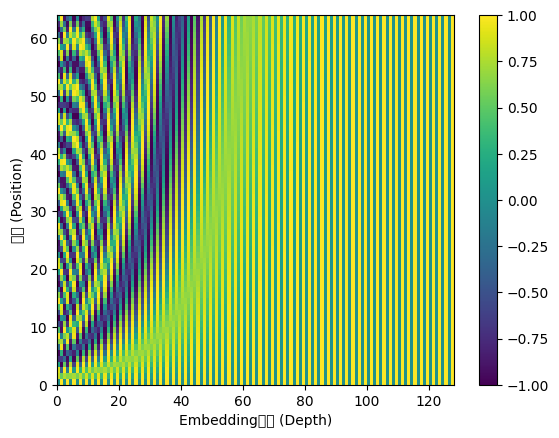

In [21]:
class TransformerEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        # ======= 超参数获取 =======
        self.vocab_size = config["vocab_size"]     # 词表大小
        self.hidden_size = config["d_model"]       # 词向量/embedding 的维度
        self.pad_idx = config["pad_idx"]           # PAD符号的索引，用于填充
        dropout_rate = config["dropout"]           # Dropout随机失活率
        self.max_length = config["max_length"]     # 句子允许的最大长度

        # 这里的max_length指的是Transformer Embedding用于构建位置编码的最大句子长度，
        # 它限定了模型在计算位置嵌入时能够支持的最大序列长度。
        # 这个值通常需要和数据处理/生成样本时（如Tokenizer、DataLoader等使用的max_length）保持一致，
        # 这样模型在输入张量时不会因为超长而出错，也不会浪费多余的位置嵌入空间。
        # 前面的max_length（如config["max_length"]、collate时的max_length）作用于数据预处理和张量裁剪，
        # 而Embedding里的max_length决定了可用的位置嵌入容量。二者通常建议设置成一样。

        # ======= 层定义 =======
        # 1. 词嵌入层（Embedding），pad的位置全为0且不参与参数更新
        self.word_embedding = nn.Embedding(
            self.vocab_size, self.hidden_size, padding_idx=self.pad_idx
        )
        # 2. 位置嵌入层，直接用Sin-Cos型的位置编码初始化（不可学习）
        self.pos_embedding = nn.Embedding(
            self.max_length,
            self.hidden_size,
            _weight=self.get_positional_encoding(
                self.max_length, self.hidden_size
            ), # 位置嵌入权重直接用经典绝对位置编码
        )
        self.pos_embedding.weight.requires_grad_(False) # 位置编码不参与训练参数更新（不是可学习参数）
        # 3. Dropout层，防止过拟合
        self.dropout = nn.Dropout(dropout_rate)

    def get_word_embedding_weights(self):
        """获取 word_embedding 层的权重（常用作权重共享）"""
        return self.word_embedding.weight

    @classmethod
    def get_positional_encoding(self, max_length, hidden_size):
        """
        计算经典的Sinusoidal位置编码，返回张量shape=[max_length, hidden_size]。
        每一行编码某个位置，每一列为该位置的某个频率下的sin/cos特征。
        公式参考Attention is All You Need论文。
        """
        # 创建全零位置编码矩阵
        pe = torch.zeros(max_length, hidden_size)

        # position: shape=[max_length, 1]，表示每个位置的整数编号（如[0,1,2,...,max_length-1]）
        # 这里使用 unsqueeze(1) 是为了把 position 变成 [max_length, 1] 的二维张量。这样在后续和 div_term 相乘时，
        # 可以利用广播机制生成 [max_length, hidden_size//2] 的矩阵，从而方便计算每个位置（不同行）在每个偶数/奇数embedding维度（不同列）对应的sin/cos值。
        position = torch.arange(0, max_length).unsqueeze(1)
        # div_term: shape=[hidden_size/2,]，为偶/奇index用不同的缩放因子
        div_term = torch.exp(
            torch.arange(0, hidden_size, 2)
            * -(torch.log(torch.Tensor([10000.0])) / hidden_size)
        )
        # 对偶数索引维度用sin
        pe[:, 0::2] = torch.sin(position * div_term)

        # 对奇数索引维度用cos
        # 切片语法用于从序列类型（如张量、列表、numpy数组等）中提取部分元素，格式为sequence[start:stop:step]
        # - start: 起始索引（包含），如果省略则从头开始
        # - stop: 结束索引（不包含），如果省略则到结尾
        # - step: 步长（可选），默认为1
        # 例如，a[1:5:2] 表示从索引1到4，每隔1个取一个（即索引1, 3）；a[::2] 表示所有偶数位置元素
        # 在pe[:, 0::2]中，表示对所有行、所有偶数列进行操作；pe[:, 1::2]对所有奇数列操作。
        pe[:, 1::2] = torch.cos(position * div_term)
        # 返回shape=[max_length, hidden_size]的张量
        return pe

    def forward(self, input_ids):
        """
        输入: input_ids [batch_size, seq_len]
        输出: 词嵌入+位置嵌入+Dropout后的整体embedding, shape=[batch_size, seq_len, hidden_size]
        """
        seq_len = input_ids.shape[1]
        assert (
            seq_len <= self.max_length
        ), f"input sequence length should no more than {self.max_length} but got {seq_len}"

        # 生成每个样本的每个位置的绝对位置编号：[0,1,...,seq_len-1]，扩展到batch维度
        position_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids) # shape=[batch, seq_len]

        # 虽然位置编码(pe)本身参数在模型初始化后固定不变（不参与参数更新），
        # 但每条输入序列长度(seq_len)可能不同，forward里要动态生成batch中的每个token的实际位置编号(position_ids)，
        # 再根据这些编号查出对应的绝对位置编码片段（通常precompute成 max_length x d_model，slice其中前seq_len行）。
        # 此外，将position_ids沿batch扩展/对齐、送到pe的embedding查表，与tokens的词向量word_embeds按位相加，这些都需要在forward里完成，
        # 以保证输入兼容变长序列和不同device，不是简单地在init时完成就能通用，必须每次前向推理时与输入同步"取用"。

        # 1. 词嵌入 [batch, seq_len, hidden_size]
        word_embeds = self.word_embedding(input_ids)
        # 2. 位置嵌入 [batch, seq_len, hidden_size]
        
        # 这样传参，即self.pos_embedding(position_ids)，实际上是通过调用nn.Embedding的forward方法，
        # 其中position_ids作为输入，张量形状为[batch_size, seq_len]，内容是每个位置的编号（如[0,1,2,...,seq_len-1]），
        # nn.Embedding会把每个编号查找成d_model维度的向量，输出shape也是[batch_size, seq_len, hidden_size]。
        # 所以这里相当于“查表”获得每个token的绝对位置向量（对应embedding）。
        pos_embeds = self.pos_embedding(position_ids)
        # 3. 嵌入相加，形式化编码token顺序信息
        embeds = word_embeds + pos_embeds
        # 4. Dropout
        embeds = self.dropout(embeds)
        return embeds


def plot_position_embedding(position_embedding):
    """
    可视化位置编码矩阵 position_embedding: shape=[max_length, hidden_size]
    行为不同的位置，列为不同的embedding维度
    """
    plt.pcolormesh(position_embedding)   # 单色块排列渲染
    plt.xlabel('Embedding维度 (Depth)')
    plt.ylabel('位置 (Position)')
    plt.colorbar()                      # 右侧添加标尺
    plt.show()

# ==== 测试/可视化Sin-Cos位置编码 ====
position_embedding = TransformerEmbedding.get_positional_encoding(64, 128)
plot_position_embedding(position_embedding)



In [22]:
import math
#为了理解指数对数变换
def positional_encoding_weights(emb_size):
    # 计算底数和指数
    base = math.log(10000)
    exponent = -5 / emb_size
    
    # 应用指数函数
    weight = math.exp(exponent*base) 
    
    return weight

emb_size = 10  # 举例，可以替换成你需要的大小
weight = positional_encoding_weights(emb_size)
print(weight)

0.009999999999999995


In [23]:
1/10000**(1/2)

0.01

In [24]:
# 随机生成输入，并测试TransformerEmbedding模块

# 定义embedding层的配置字典
config = {
    "vocab_size": 100,   # 词表大小为100（假定有100个token类型）
    "d_model": 128,      # 每个token的embedding维度为128
    "pad_idx": 0,        # padding的索引为0
    "max_length": 64,    # 句子的最大长度为64
    "dropout": 0.1,      # dropout比例为0.1
}

# 随机生成输入token的下标，形状为[batch_size=2, seq_len=50]
# 元素范围为[0, 100)，即模拟2个句子，每个句子长度为50
input_ids = torch.randint(0, 100, (2, 50))

# 初始化TransformerEmbedding，并传入input_ids得到embedding结果
# embedding输出的形状应为[batch_size, seq_len, d_model]，即[2, 50, 128]

# 这两个括号用于初始化TransformerEmbedding并进行前向传播（即把input_ids输入embedding层并输出embeds）。
# 第一个括号：TransformerEmbedding(config)
#   作用：实例化一个TransformerEmbedding对象，传入配置字典config。
# 第二个括号：(input_ids)
#   作用：调用前面实例化好的对象的__call__方法（本质是forward），对输入input_ids进行embedding变换，得到embedding结果。

embeds = TransformerEmbedding(config)(input_ids)

# 打印embedding的shape，确认输出维度是否正确
embeds.shape

torch.Size([2, 50, 128])

### Transformer Block

#### scaled-dot-product-attention

In [25]:
from dataclasses import dataclass
from typing import Optional, Tuple

Tensor = torch.Tensor

# @dataclass 是 Python 标准库 dataclasses 中的一个装饰器，用于简化数据类（data class）的定义。
# 现在我们用 @dataclass 为 AttentionOutput 自动生成了如 __init__、__repr__ 等方法，只需声明属性即可，无需手动写构造方法。
# 下面这个 AttentionOutput 数据类用于封装注意力模块的输出，包括每个 token 的新表示（hidden_states）和每个注意力头的分数（attn_scores）。

@dataclass
class AttentionOutput:
    hidden_states: Tensor          # 输出的每个token的表示
    attn_scores: Tensor            # 注意力分数（softmax后的分布）

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        """
        多头注意力机制模块
        Args:
            config (dict): 包含模型的超参数配置，包括 d_model、num_heads 等
        """
        super().__init__()
        # ============ 超参数 ============
        self.hidden_size = config["d_model"]    # 输入/输出隐藏层维度（如: 512）
        self.num_heads = config["num_heads"]    # 多头注意力的头数（如: 8）
        
        # 检查 hidden_size 是否可以整除 num_heads
        assert (
            self.hidden_size % self.num_heads == 0
        ), "Hidden size must be divisible by num_heads but got {} and {}".format(
            self.hidden_size, self.num_heads
        )
        self.head_dim = self.hidden_size // self.num_heads # 每个头的隐藏维度（如: 64）

        # ============ 权重层定义 ============
        # 以下四个全连接层分别实现 Q/K/V/输出的线性映射，不带偏置
        self.Wq = nn.Linear(self.hidden_size, self.hidden_size, bias=False) # Query 的线性变换
        self.Wk = nn.Linear(self.hidden_size, self.hidden_size, bias=False) # Key 的线性变换
        self.Wv = nn.Linear(self.hidden_size, self.hidden_size, bias=False) # Value 的线性变换
        self.Wo = nn.Linear(self.hidden_size, self.hidden_size, bias=False) # 多头输出的线性变换

    def _split_heads(self, x: Tensor) -> Tensor:
        """
        将输入张量切分为多头
        输入: [batch_size, seq_len, hidden_size]
        输出: [batch_size, num_heads, seq_len, head_dim]
        """
        bs, seq_len, _ = x.shape
        # 将hidden_size维度切分成[num_heads, head_dim]
        x = x.view(bs, seq_len, self.num_heads, self.head_dim)
        # 调整维度顺序，将num_heads移到第二维
        return x.permute(0, 2, 1, 3)

    def _merge_heads(self, x: Tensor) -> Tensor:
        """
        合并多头的输出
        输入: [batch_size, num_heads, seq_len, head_dim]
        输出: [batch_size, seq_len, hidden_size]
        """
        bs, _, seq_len, _ = x.shape
        # 先将 seq_len 移回第二维，再串联所有头的输出
        return x.permute(0, 2, 1, 3).reshape(bs, seq_len, self.hidden_size)

    def forward(self, querys, keys, values, attn_mask=None) -> AttentionOutput:
        """
        前向传播
        Args:
            querys: [batch_size, seq_len, hidden_size] 查询（Q）
            keys:   [batch_size, seq_len_k, hidden_size] 键（K）
            values: [batch_size, seq_len_k, hidden_size] 值（V）
            attn_mask: 可选，注意力掩码，形状 [batch_size, num_heads, seq_len, seq_len_k]。为1的位置将被mask
        Returns:
            AttentionOutput对象，包含 attention 矩阵以及输出表示
        """
        # ---- 1. 输入线性变换 + 拆分多头 ----
        querys = self._split_heads(self.Wq(querys))  # [bs, num_heads, seq_len, head_dim]
        keys   = self._split_heads(self.Wk(keys))    # [bs, num_heads, seq_len_k, head_dim]
        values = self._split_heads(self.Wv(values))  # [bs, num_heads, seq_len_k, head_dim]

        # ---- 2. 计算注意力分数 ----
        # Q @ K^T 进行点积相似度，[:, :, seq_len_q, head_dim] @ [:, :, head_dim, seq_len_k]
        # 结果：[batch_size, num_heads, seq_len_q, seq_len_k]
        qk_logits = torch.matmul(querys, keys.mT)
        # qk_logits: [bs, num_heads, seq_len_q, seq_len_k]
        # print(querys.shape[-2], keys.shape[-2])  #3 4

        # ---- 3. 应用mask（如果有）----
        if attn_mask is not None:
            # 保证mask与qk_logits shape相同，多余部分自动裁剪
            attn_mask = attn_mask[:, :, : querys.shape[-2], : keys.shape[-2]]
            # 需要mask的位置加上一个极大负数，使得softmax后为0
            qk_logits += attn_mask * -1e9

        # ---- 4. softmax归一化（并缩放），获得注意力分数 ----
        attn_scores = F.softmax(qk_logits / (self.head_dim**0.5), dim=-1) # dim=-1在seq_len_k维度上归一化

        # ---- 5. 注意力聚合 ----
        # 将注意力分数与values加权求和, 得到每个query的聚合表示
        # [bs, num_heads, seq_len_q, seq_len_k] @ [bs, num_heads, seq_len_k, head_dim] = [bs, num_heads, seq_len_q, head_dim]
        embeds = torch.matmul(attn_scores, values)

        # ---- 6. 合并多头&输出线性映射 ----
        # [bs, num_heads, seq_len_q, head_dim] -> [bs, seq_len_q, hidden_size] -> [bs, seq_len_q, hidden_size]
        embeds = self.Wo(self._merge_heads(embeds))

        # ---- 7. 返回 注意力输出对象 ----
        return AttentionOutput(hidden_states=embeds, attn_scores=attn_scores)


# =================== 测试用例 ===================

# 构建一个简单的2头、隐藏维度为2的多头注意力，用于功能测试
mha = MultiHeadAttention({"num_heads": 2, "d_model": 2})

# 随机生成输入的query张量，形状[batch_size=2, seq_len=3, hidden_size=2]
query = torch.randn(2, 3, 2)  # [2, 3, 2]
# 对每一行向量做L2归一化，便于验证
query /= query.norm(dim=-1, keepdim=True)

# 随机生成key和value，形状[batch_size=2, seq_len=4, hidden_size=2]
key_value = torch.randn(2, 4, 2)

print(f'key_value.shape {key_value.shape}') # 打印shape, 期望输出: torch.Size([2, 4, 2])

# 执行前向传播，多头注意力
outputs = mha(query, key_value, key_value) # 最终输出的hidden_states.shape应该与query一致

# 输出hidden_states形状: [batch_size, seq_len, hidden_size]
print(outputs.hidden_states.shape) # 预期: torch.Size([2, 3, 2])
# 输出attn_scores形状: [batch_size, num_heads, seq_len, seq_len_of_keys]
print(outputs.attn_scores.shape)   # 预期: torch.Size([2, 2, 3, 4])

key_value.shape torch.Size([2, 4, 2])
torch.Size([2, 3, 2])
torch.Size([2, 2, 3, 4])


In [26]:
#随机一个2阶张量，在-1维度计算softmax
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

x = torch.randn(2, 3)
x_softmax = F.softmax(x, dim=-1)
print(x_softmax)



tensor([[0.0302, 0.9140, 0.0558],
        [0.4426, 0.4996, 0.0578]])


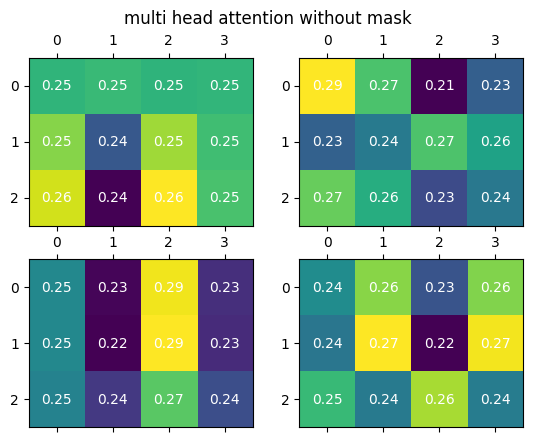

In [27]:
# 使用 plt.subplots() 创建一个子图网格
# outputs.attn_scores 的前两个维度分别为 batch_size 与 num_heads，作为子图的行数和列数
fig, axis = plt.subplots(*outputs.attn_scores.shape[:2])

# 遍历每个 batch（i 轴）
for i in range(query.shape[0]):
    # 遍历每个注意力头（j 轴）
    for j in range(outputs.attn_scores.shape[1]):
        # 绘制第 i 个 batch、第 j 个 attention head 的注意力分数热力图
        # outputs.attn_scores[i, j] 的 shape: [查询序列长度, 键序列长度]
        # .detach().numpy() 将张量转为 numpy 数组用于显示
        axis[i, j].matshow(outputs.attn_scores[i, j].detach().numpy())

        # 遍历查询序列长度和键序列长度，将注意力分数数值标在热力图每个格子中
        for x in range(outputs.attn_scores.shape[2]):  # 遍历查询序列
            for y in range(outputs.attn_scores.shape[3]):  # 遍历键序列
                # f"{outputs.attn_scores[i, j, x, y]:.2f}" 格式化成 2 位小数
                # ha="center", va="center" 让数字居中显示，color="w" 设为白色字体
                # 在热力图的每个格子中显示分数，y为列（键序列），x为行（查询序列），内容格式为两位小数
                # ha="center", va="center" 设置数字居中显示，color="w" 用白色字体
                axis[i, j].text(y, x, f"{outputs.attn_scores[i, j, x, y]:.2f}", ha="center", va="center", color="w")

# 设置图像总标题
fig.suptitle("multi head attention without mask")
# 显示绘制的所有注意力权重热力图
plt.show()

--------------------------------------------------


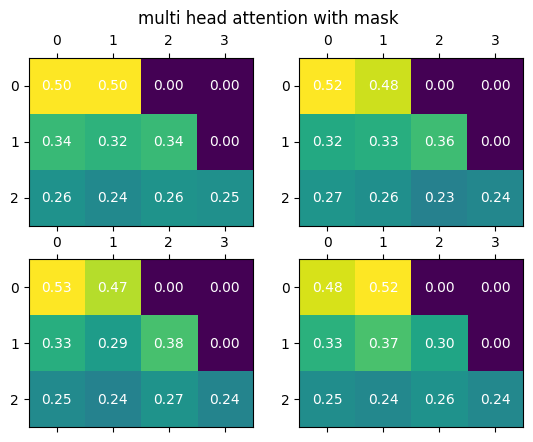

In [28]:
# 打印分隔线用于区分输出内容
print('-'*50)
# 构造手动定义的mask矩阵，用于模拟注意力机制中的mask掩码
# 该mask为形状[1, 1, 3, 4]，通用于(batch, num_heads, seq_len, seq_len_of_keys)
mask = torch.Tensor([[0, 0, 1, 1], 
                     [0, 0, 0, 1], 
                     [0, 0, 0, 0]]).reshape(1, 1, 3, 4)  #手工构造mask，0表示可关注，1表示被mask，不可关注

# 将自定义mask作为参数输入多头注意力机制mha
# 注意，mask通常用于防止模型关注未来的信息（自回归）或padding位置
outputs_masked = mha(query, key_value, key_value, mask)

# 创建子图网格，每个(batch, num_head)一个子图，用于可视化注意力分数
fig, axis = plt.subplots(*outputs_masked.attn_scores.shape[:2])

# 遍历每一个batch维度i
for i in range(query.shape[0]):
    # 遍历每一个头部维度j
    for j in range(outputs_masked.attn_scores.shape[1]):
        # 绘制注意力分数热力图
        # .detach().numpy()将tensor转为numpy方便matplotlib绘制
        axis[i, j].matshow(outputs_masked.attn_scores[i, j].detach().numpy())
        # 在每个坐标位置标上数值，方便直观观察数值分布
        for x in range(outputs_masked.attn_scores.shape[2]):   # 查询长度
            for y in range(outputs_masked.attn_scores.shape[3]):  # 关键序列长度
                axis[i, j].text(
                    y, x, 
                    f"{outputs_masked.attn_scores[i, j, x, y]:.2f}",    # 格式化到小数点后两位
                    ha="center", va="center", color="w"    # 字体居中、白色字体
                )

# 设置整个画布的标题，说明mask生效的注意力可视化
fig.suptitle("multi head attention with mask")
# 展示绘制好的所有注意力热力图子图
plt.show()

#### Transformer-Block

In [29]:
# 使用@dataclass装饰器，会自动生成__init__、__repr__、__eq__等常用方法，方便数据类的调用与管理
@dataclass
class TransformerBlockOutput:
    # hidden_states: Tensor
    # 存储当前Transformer Block输出的隐藏状态，作为后续模块的输入
    hidden_states: Tensor

    # self_attn_scores: Tensor
    # 存储Self-Attention过程中，各位置对其它位置的注意力分数（权重矩阵）
    self_attn_scores: Tensor

    # cross_attn_scores: Optional[Tensor] = None
    # （只有Decoder Block时非None）记录交叉注意力分数，若非Decoder则为None
    cross_attn_scores: Optional[Tensor] = None


# Encoder和Decoder（训练时）输入、输出的seq_len通常保持一致。保证这一点主要基于两点：
# 1. 计算时，Transformer的Attention和FFN均对每个位置并行，多少输入token产生多少个输出hidden_state，输出shape和输入seq_len一致。
# 2. 训练和Teacher Forcing推理中，Decoder输入和target标签对齐，seq_len同步。
#
# 但在推理阶段（infer/生成），通常自回归逐步解码，每次生成1个新token，因此infer阶段输出的seq_len会随着生成逐步增加，直到最大长度或遇到eos结束。

class TransformerBlock(nn.Module):
    """
    Transformer的核心模块(Block)，既可作为Encoder也可作为Decoder中的子层。
    支持自注意力（Self-Attention）、前馈网络（FFN）和可选的交叉注意力（Cross-Attention）。
    """
    def __init__(self, config, add_cross_attention=False):
        """
        初始化TransformerBlock。
        Args:
            config: 配置字典，包含hidden size、头数、dropout、FFN维度、layer norm eps等参数。
            add_cross_attention: 是否添加交叉注意力（Decoder需要，Encoder不需要）。
        """
        super().__init__()
        # === 1. 读取配置参数 ===
        self.hidden_size = config["d_model"]            # 隐藏层维度
        self.num_heads = config["num_heads"]           # 注意力头数
        dropout_rate = config["dropout"]               # dropout比例
        ffn_dim = config["dim_feedforward"]            # FFN中间层维度
        eps = config["layer_norm_eps"]                 # LN的epsilon

        # === 2. 自注意力子层 (Self-Attention Block) ===
        self.self_atten = MultiHeadAttention(config)   # 多头自注意力
        self.self_ln = nn.LayerNorm(self.hidden_size, eps=eps)  # 层归一化
        self.self_dropout = nn.Dropout(dropout_rate)   # dropout

        # === 3. 交叉注意力子层 (Cross-Attention Block，仅Decoder需要) ===
        # Decoder需要与Encoder输出进行交互
        if add_cross_attention:
            self.cross_atten = MultiHeadAttention(config)                # 交叉注意力
            self.cross_ln = nn.LayerNorm(self.hidden_size, eps=eps)      # 层归一化
            self.cross_dropout = nn.Dropout(dropout_rate)                # dropout
        else:
            self.cross_atten = None    # Encoder不使用交叉注意力

        # === 4. 前馈神经网络（FFN） ===
        # 两层Linear组成的前馈网络
        self.ffn = nn.Sequential(
            nn.Linear(self.hidden_size, ffn_dim),     # 升维
            nn.ReLU(),                                # 激活
            nn.Linear(ffn_dim, self.hidden_size),      # 降维
        )
        self.ffn_ln = nn.LayerNorm(self.hidden_size, eps=eps)       # 层归一化
        self.ffn_dropout = nn.Dropout(dropout_rate)                 # dropout

    def forward(
        self,
        hidden_states,     # 输入隐藏状态（batch, seq_len, hidden_dim）
        attn_mask=None,    # （可选）自注意力用的mask，比如padding或未来mask
        encoder_outputs=None,      # （可选，仅Decoder用）Encoder结果，用于交叉注意力
        cross_attn_mask=None,      # （可选）交叉注意力mask
    ):
        """
        完整前向传播包括：1)自注意力、2)交叉注意力（可选）、3)FFN，每步都有残差+LayerNorm。

        Args:
            hidden_states: 输入隐藏状态
            attn_mask: 自注意力mask（可遮挡padding/未来信息）
            encoder_outputs: Decoder阶段，来自Encoder的hidden_states
            cross_attn_mask: 交叉注意力mask
        Returns:
            TransformerBlockOutput，包含本层的输出、self/cross attention分数
        """

        # ===== 1. 自注意力 =====
        # 自身序列每个位置与其它位置做注意力
        self_atten_output = self.self_atten(
            hidden_states,     # Q
            hidden_states,     # K
            hidden_states,     # V
            attn_mask          # mask
        )
        # 残差+LayerNorm
        self_embeds = self.self_ln(
            hidden_states + self.self_dropout(self_atten_output.hidden_states)
        )
        # self_embeds = LayerNorm(input + Dropout(SelfAttention(input)))

        # ===== 2. 交叉注意力（仅Decoder用） =====
        # Decoder时才处理交叉注意力
        if self.cross_atten is not None:
            assert encoder_outputs is not None, "encoder_outputs不能为空（Decoder需要Encoder输出）"
            # Decoder当前层输出为Q，Encoder输出为K,V
            cross_atten_output = self.cross_atten(
                self_embeds,        # Q
                encoder_outputs,    # K
                encoder_outputs,    # V
                cross_attn_mask     # mask
            )
            # 残差+LayerNorm
            cross_embeds = self.cross_ln(
                self_embeds + self.cross_dropout(cross_atten_output.hidden_states)
            )
            # cross_embeds = LayerNorm(self_embeds + Dropout(CrossAttention(self_embeds, encoder_outputs)))

        # ===== 3. 前馈网络(FFN) =====
        # 输入：优先使用交叉注意力输出（如有），否则用自注意力输出
        embeds = cross_embeds if self.cross_atten is not None else self_embeds
        ffn_output = self.ffn(embeds)
        # 残差+LayerNorm
        embeds = self.ffn_ln(embeds + self.ffn_dropout(ffn_output))
        # embeds = LayerNorm(embeds + Dropout(FFN(embeds)))

        # ===== 4. 打包输出结果 =====
        # 返回TransformerBlockOutput，包含最终输出hidden_states，各注意力分数
        # cross_attn_scores: 若有交叉注意力则返回分数，否则为None
        return TransformerBlockOutput(
            hidden_states=embeds,                                 # Block输出
            self_attn_scores=self_atten_output.attn_scores,       # 自注意力分数
            cross_attn_scores=cross_atten_output.attn_scores
            if self.cross_atten is not None
            else None,
        )

#### Encoder

In [30]:
from typing import List

# TransformerEncoderOutput 用于存储编码器的输出结果
@dataclass
class TransformerEncoderOutput:
    last_hidden_states: Tensor   # 编码器最后一层的隐藏状态 (形状通常为：batch_size × seq_len × hidden_dim)
    attn_scores: List[Tensor]    # 每一层的自注意力分数列表（每个元素是一个 attention scores 张量）

# TransformerEncoder实现Transformer编码器结构
# 详细流程参考官方文档：https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module
class TransformerEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        # 获取编码器堆叠的层数（即有多少个TransformerBlock模块）
        self.num_layers = config["num_encoder_layers"]

        # 创建self.layers,它是一个 nn.ModuleList，包含了 self.num_layers 个TransformerBlock。
        # 注意：ModuleList只是一个持有子模块的列表，它本身并不实现前向计算操作。

        # ModuleList和Sequential的区别：
        # 1. nn.ModuleList只是一个持有子模块的列表，不实现前向传播，即forward()时不会自动顺序调用其中的模块；而nn.Sequential会把其中的模块顺序串联起来自动执行forward。
        # 2. 用ModuleList时可以灵活控制每一层前向传播的具体操作，比如本例中每一层的输入输出等，可以手动定制每层的调用过程和额外的保存/分析；而Sequential适合所有层结构和流程都完全一致且是简单串联的情况。
        # 这里用ModuleList，是因为Transformer编码器的每一层除了forward以外，还需要将每一层的attention scores单独保存到列表，以便后续用于可视化或分析attention分布等。如果用Sequential，就无法这样灵活地插入额外的处理或保存中间产物。
        self.layers = nn.ModuleList(
            [TransformerBlock(config) for _ in range(self.num_layers)]
        )

    def forward(
        self, encoder_inputs_embeds, attn_mask=None
    ) -> TransformerEncoderOutput:
        """
        Args:
            encoder_inputs_embeds: 编码器的输入嵌入张量（通常是词嵌入和位置编码的和）。
            attn_mask: (可选) 用于掩蔽注意力的mask张量。形状与输入序列相关，控制哪些位置可以被注意到。

        Returns:
            TransformerEncoderOutput，包含最后一层隐藏状态和每层的自注意力分数列表。
        """
        attn_scores = [] # 用于存储每一层的自注意力分数（可用于可视化分析模型关注位置）
        embeds = encoder_inputs_embeds # 初始化输入嵌入向量，作为第一个TransformerBlock的输入

        # 逐层堆叠TransformerBlock，依次前向传播
        for layer in self.layers:
            # 每个layer都是一个TransformerBlock，返回一个TransformerBlockOutput对象
            block_outputs = layer(embeds, attn_mask=attn_mask)
            # 取出当前层的输出，作为下一层的输入
            embeds = block_outputs.hidden_states
            # 保存当前层的自注意力分数到 attn_scores（之后可用来分析注意力分布或画图）
            attn_scores.append(block_outputs.self_attn_scores)

        # 最后，返回编码器的最终输出（最后一层隐藏状态+每层的自注意力分数）
        return TransformerEncoderOutput(
            last_hidden_states=embeds, attn_scores=attn_scores
        )
    


#### Decoder

In [31]:
@dataclass
class TransformerDecoderOutput:
    last_hidden_states: Tensor
    self_attn_scores: List[Tensor]
    cross_attn_scores: List[Tensor]


class TransformerDecoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        # hyper params
        self.num_layers = config["num_decoder_layers"]

        # layers
        self.layers = nn.ModuleList(
            [
                TransformerBlock(config, add_cross_attention=True)
                for _ in range(self.num_layers)
            ]
        )

    def forward(
        self,
        decoder_inputs_embeds,
        encoder_outputs,
        attn_mask=None,
        cross_attn_mask=None,
    ) -> TransformerDecoderOutput:
        self_attn_scores = [] # 存储每个层的自注意力分数
        cross_attn_scores = [] # 存储每个层的交叉注意力分数
        embeds = decoder_inputs_embeds # 输入的嵌入向量作为第一层的输入(embedding+位置编码)
        for layer in self.layers:
            block_outputs = layer(
                embeds,
                attn_mask=attn_mask, # 自注意力的mask
                encoder_outputs=encoder_outputs,
                cross_attn_mask=cross_attn_mask, # 交叉注意力的mask
            )
            embeds = block_outputs.hidden_states # 上一层的输出作为下一层的输入
            self_attn_scores.append(block_outputs.self_attn_scores) # 存储每个层的自注意力分数,为了画图
            cross_attn_scores.append(block_outputs.cross_attn_scores) # 存储每个层的交叉注意力分数，为了画图

        return TransformerDecoderOutput(
            last_hidden_states=embeds,
            self_attn_scores=self_attn_scores,
            cross_attn_scores=cross_attn_scores,
        )


#### mask

- mask实际上大类上只有两种
    1. `padding_mask`：mask掉`pad_idx`，不计算损失
    2. `attention_mask`：mask掉`pad_idx`，不计算注意力分数
- Decoder的`attention_mask`和Encoder有一定的区别：
    - Encoder可以同时看见序列所有信息，故只mask掉`pad_idx`
    - Decoder只能看到在自身之前的序列的信息，故要额外mask掉自身之后的序列

In [32]:
# 创建一个 5x5 的全1矩阵
ones_matrix = torch.ones(5, 5)
# 使用 torch.triu 得到该矩阵的上三角部分（包含主对角线），下三角部分为0
upper_triangular = torch.triu(ones_matrix)
# 判断哪些元素等于0，将下三角部分（包括主对角线以下）置为True，其余为False
mask = (upper_triangular == 0)
# 输出结果，mask的True表示这些位置需要被mask
print(mask)

tensor([[False, False, False, False, False],
        [ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False]])


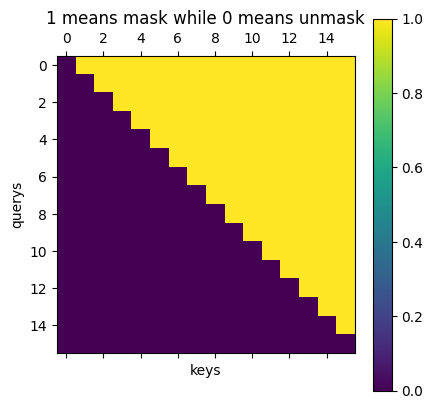

In [33]:

def generate_square_subsequent_mask(sz: int) -> Tensor:
    """
    生成一个自回归（look-ahead）mask，用于Transformer解码器的自注意力层，确保每个位置只能看到之前（含自身）的位置，
    屏蔽（mask）掉后续的信息，防止信息泄露。
    
    # 最大解码长度（max_length）通常指在序列到序列（seq2seq）生成任务（比如机器翻译）中，模型在预测目标序列（target sequence/译文）时，最多会依次生成多少个token（词/子词）。该上限防止生成过程变得无限长，通常设置为一个足够覆盖大部分句子长度的数值，例如128。
    # 具体到generate_square_subsequent_mask(sz)这个函数，sz就代表本次要生成的“目标序列长度”，一般为max_length。该mask确保Transformer解码器在生成每个位置的token时，只能看到本token及其之前的token，实现自回归、左掩码机制。

    参数:
        sz (int): 输入序列长度（即query和key的长度，通常等于最大解码长度）。
    
    返回:
        mask (Tensor): shape为[sz, sz]的布尔型tensor。
                        - 位置为True的元素表示需要mask（不允许关注/访问），
                        - 位置为False的元素表示可正常关注/访问。

    mask矩阵解释：
        - mask[i, j] = True  表示第i个位置(query)不能看到第j个位置(key)
        - mask[i, j] = False 表示第i个位置(query)可以看到第j个位置(key)
        - 对于i < j，即query在key之前的情况，需要mask（防止信息泄露），即True
        - 对于i >= j，query可以看到自身和之前的key
    """
    # 创建一个shape为(sz, sz)的全1矩阵。此矩阵可视为每个query（行）对应每个key（列）的关联关系。
    ones_matrix = torch.ones(sz, sz)
    # 使用torch.triu取得该矩阵的上三角（包含主对角线），即对于i<=j的位置是1，其余为0
    # (此时mask的位置暂为0)
    upper_triangular = torch.triu(ones_matrix)
    # ==0操作将上三角（含对角线）变为False，下三角部分变为True（即i<=j为False，i>j为True）
    # 注意，这里和常见实现的顺序不同，为了与官方接口兼容，需要转置（transpose）一次
    # transpose(-1, -2)将行列交换，使得mask[i,j]=True when j>i
    mask = (upper_triangular == 0).transpose(-1, -2).bool()
    # 返回mask矩阵，类型为bool，True代表masked（不能访问），False代表unmasked（能访问）
    return mask

# 画出一个16x16的mask矩阵的热力图
# generate_square_subsequent_mask(16)会生成一个16x16的布尔mask，黄色（1）代表True，即masked位置
plt.matshow(generate_square_subsequent_mask(16))
plt.colorbar()  # 显示色条，帮助辨别True/False
plt.xlabel("keys")  # 横轴：key位置
plt.ylabel("querys")  # 纵轴：query位置
plt.title("1 means mask while 0 means unmask")  # 标题解释
plt.show()


tensor([[    1,     2, 10380,   125,     2,   337,   143,    10,     2,    57,
             4,     3]])
['[BOS]', '[UNK]', 'quick', 'brown', '[UNK]', 'jumps', 'over', 'the', '[UNK]', 'dog', '.', '[EOS]']


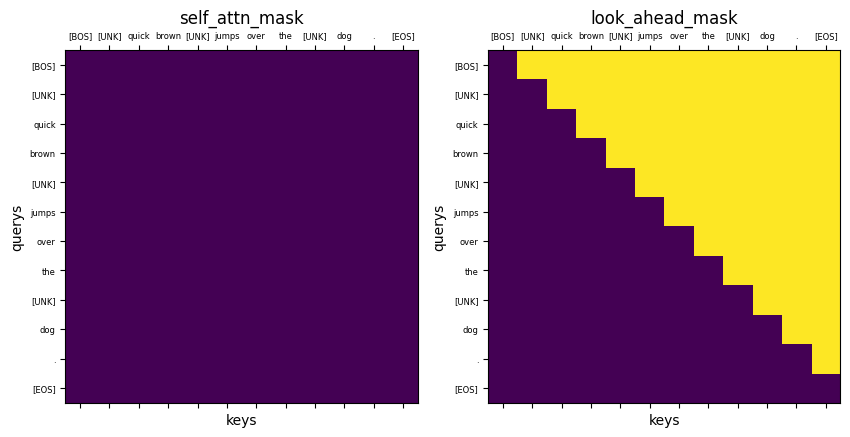

--------------------------------------------------
tensor([[   1,    2,  768,   10,    2, 5139, 3702,    3,    0,    0,    0,    0]])
['[BOS]', '[UNK]', 'does', 'the', '[UNK]', 'say', '?', '[EOS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


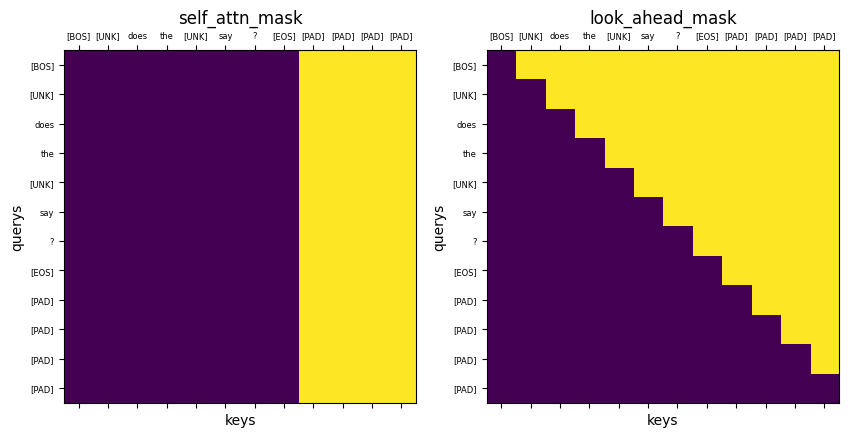

--------------------------------------------------


In [34]:
# 下面代码用于可视化和分析Transformer中不同类型mask（掩码）的结构和作用，便于理解模型注意力的屏蔽机制

# 定义输入的英文句子列表（即batch内的两条不同语句）
inputs_words = [
    "The quick brown fox jumps over the lazy dog .",
    "What does the fox say ?"
]

# 使用分词器将输入句子分词并编码，同时返回每个位置的pad掩码input_mask
# - inputs_ids: shape [batch, seq_len]，每个token被编码为一个id
# - input_mask: shape [batch, seq_len]，pad处为0，其余为1
inputs_ids, input_mask = tokenizer.encode([w.split() for w in inputs_words], return_mask=True)

# 遍历每一句（即batch内每个样本），可视化其self-attention mask和look-ahead mask
for i in range(len(inputs_words)):
    # 用分词器将输入句子解码回分词序列，保留所有特殊符号（如BOS, EOS, PAD），以便显示
    print(inputs_ids[i: i+1])
    decode_text = tokenizer.decode(
        inputs_ids[i: i+1].tolist(),
        remove_bos=False, remove_eos=False, remove_pad=False, split=True
    )[0]
    print(decode_text)  # 打印本句的分词序列（含特殊符号）

    # 构造self-attention中使用的padding mask
    # input_mask[i]: shape=[seq_len]，1表示非pad，0表示pad
    # 先reshape为[1, seq_len]，再将其在第0维扩展为[seq_len, seq_len]，使得每个query都屏蔽同样位置（pad）的key
    # 最终self_attn_mask为[seq_len, seq_len]。每一行都一样：query无论是谁，只要key为pad就要mask掉
    
    # self-attention里的mask是方阵（seq_len x seq_len），每个token都要对序列中所有token做attention（包括自己），
    # 因此query和key的长度一致（都是本句长度），mask为方阵
    # 如果是cross-attention（如decoder对encoder输出），query和key长度可以不一样（分别对应目标句和源句长度），
    # 这时mask的形状就是[target_seq_len, source_seq_len]，不一定是方阵
    self_attn_mask = input_mask[i].reshape(1, -1).repeat_interleave(inputs_ids.shape[-1], dim=0)
    #print(input_mask[i].reshape(1, -1).repeat_interleave(inputs_ids.shape[-1], dim=0))

    # look-ahead（下三角）mask，防止信息泄露，使得每个query只能看到包括自身及其之前的所有key
    # 输出mask: shape=[seq_len, seq_len]，True表示被mask（不可见），False表示可见
    look_ahead_mask = generate_square_subsequent_mask(inputs_ids.shape[-1])

    # 可视化两个mask
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # 左图：self-attention的padding mask。每一行相同，pad列全为mask
    axs[0].matshow(self_attn_mask)
    axs[0].set_title("self_attn_mask")
    axs[0].set_yticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[0].set_ylabel("querys")  # y轴代表query位置（当前进行注意力聚合的词）
    axs[0].set_xticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[0].set_xlabel("keys")    # x轴代表key位置（所有可能被关注的词）

    # 右图：look-ahead mask（下三角矩阵），主对角线右上的位置被mask，防止泄漏未来信息
    axs[1].matshow(look_ahead_mask)
    axs[1].set_title("look_ahead_mask")
    axs[1].set_yticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_ylabel("querys")
    axs[1].set_xticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_xlabel("keys")

    # 显示图像
    plt.show()

    # 分割线，用于区分不同句子的可视化结果
    print('-' * 50)

# 在Transformer的实现中，padding token在自注意力的key/value方向（即列）需要被mask掉，这是为了防止模型在聚合信息时把注意力分给没有意义的pad位置。
# 而对于query方向（即行），理论上pad位置对应的query是不需要被mask掉的，因为：
# （1）在生成输出时，pad所在位置不会被生成（如解码时停止在EOS或遇到PAD），模型不会在pad位置继续生成。
# （2）更重要的是，在计算最终的loss时，会针对每个token位置应用一个mask（如NLLLoss等损失函数的ignore_index，或者使用pad_mask），
#     只有非pad的位置的预测会对loss有影响。pad位置的损失项被mask掉，不会参与梯度计算（即，loss乘以0，忽略该位置）。
# 所以即使自注意力时这些行“没被mask”，只要损失函数部分实现了pad的mask，模型不会被pad位置误导，训练和测试都是正确的。

In [37]:
(torch.triu(torch.ones(5, 5)) == 0).transpose(-1, -2).bool()

tensor([[False,  True,  True,  True,  True],
        [False, False,  True,  True,  True],
        [False, False, False,  True,  True],
        [False, False, False, False,  True],
        [False, False, False, False, False]])

In [38]:

a = torch.randn(5, 1, 1, 4) #mask
b = torch.randn(5, 8, 4, 4)
(a + b).shape

torch.Size([5, 8, 4, 4])

torch.Size([2, 12])
torch.Size([2, 12])
['[BOS]', '[UNK]', 'quick', 'brown', '[UNK]', 'jumps', 'over', 'the', '[UNK]', 'dog', '.', '[EOS]']


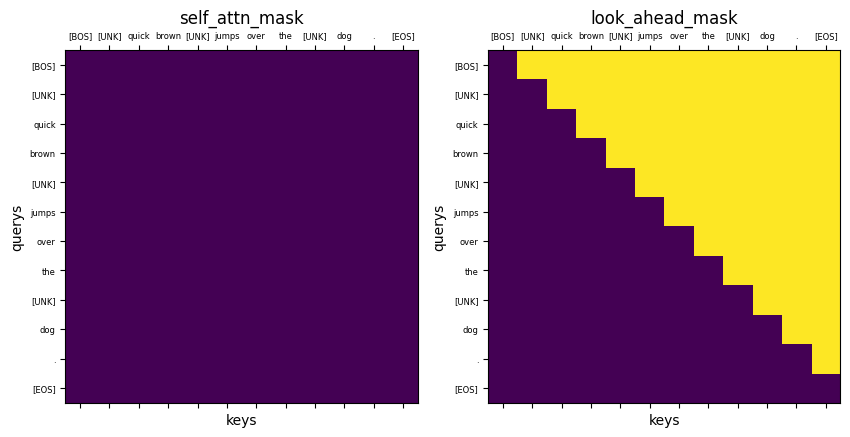

--------------------------------------------------
['[BOS]', '[UNK]', 'does', 'the', '[UNK]', 'say', '?', '[EOS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


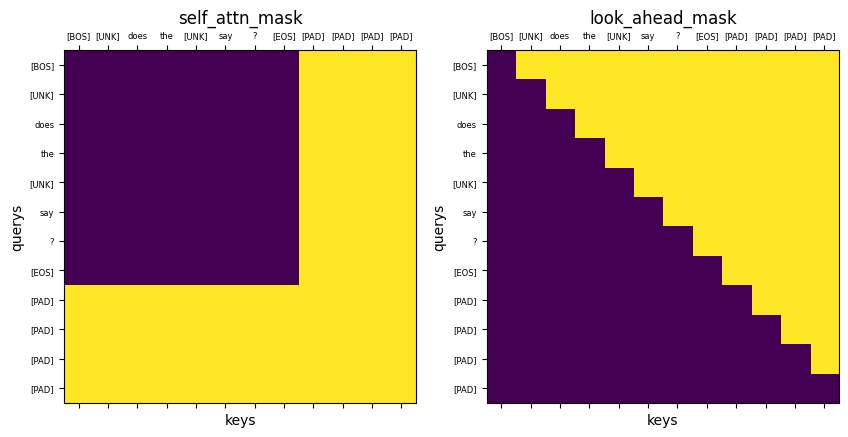

--------------------------------------------------


In [44]:
# 通过下面代码查看mask的效果并进行可视化，含详细注释

# 输入的两个英文句子，准备查看mask掩码矩阵的形状与可视化
inputs_words = ["The quick brown fox jumps over the lazy dog .", "What does the fox say ?"]

# 利用tokenizer将输入句子分词，并编码为id序列，同时生成pad位置的mask矩阵（1为pad，0为有效token）
inputs_ids, input_mask = tokenizer.encode([w.split() for w in inputs_words], return_mask=True)

# 打印编码后输入id的形状，以及对应的pad mask形状
print(inputs_ids.shape)  # [batch, seq_len]
print(input_mask.shape)  # [batch, seq_len]

# 对每个输入句子分别绘制mask
for i in range(len(inputs_words)):
    # 根据ids解码出原始的token文本，方便在可视化中做标签
    decode_text = tokenizer.decode(
        inputs_ids[i: i+1].tolist(), 
        remove_bos=False, 
        remove_eos=False, 
        remove_pad=False, 
        split=True
    )[0]
    print(decode_text)

    # ----------------- Padding Mask 生成和可视化 -----------------
    # padding mask作用：mask掉输入中的padding token，避免模型对pad位置聚合注意力
    # 列mask，表示：所有query（行）都对pad的key（列）做mask
    col_mask = input_mask[i].reshape(1, -1).repeat_interleave(inputs_ids.shape[-1], dim=0)
    # 行mask，表示：pad位置自身也不参与向其他query聚合注意力。所有被mask的query不聚合任何key
    row_mask = input_mask[i].reshape(-1, 1).repeat_interleave(inputs_ids.shape[-1], dim=1)
    # 行mask和列mask求or： 只要为pad的行或列都置为True，作为最终的padding self-attention mask
    self_attn_mask = col_mask | row_mask

    # ----------------- Look-ahead Mask 生成和可视化 -----------------
    # Look-ahead mask（下三角mask）：防止decoder自回归解码时“偷看”未来信息，保证序列生成的因果性
    # 其shape为[seq_len, seq_len]，上三角为True（mask），下三角及主对角线为False（可见）
    look_ahead_mask = generate_square_subsequent_mask(inputs_ids.shape[-1])

    # 可视化padding mask与look-ahead mask
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    # 左图：self-attention的padding mask（包括行和列的pad位置均为True，深色显示）
    axs[0].matshow(self_attn_mask)
    axs[0].set_title("self_attn_mask")
    axs[0].set_yticks(range(len(decode_text)), decode_text, fontsize=6)  # y轴标记为原始token
    axs[0].set_ylabel("querys")  # y轴为query token
    axs[0].set_xticks(range(len(decode_text)), decode_text, fontsize=6)  # x轴标记为原始token
    axs[0].set_xlabel("keys")    # x轴为key token

    # 右图：look-ahead mask（下三角为False，主对角及其下方可见；防止信息泄露）
    axs[1].matshow(look_ahead_mask)
    axs[1].set_title("look_ahead_mask")
    axs[1].set_yticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_ylabel("querys")
    axs[1].set_xticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_xlabel("keys")

    plt.show()  # 显示mask可视化
    print('-'*50)  # 分割线区分不同句子的可视化结果

    

# 为什么行部分的padding没有mask掉，在最终计算loss的时候，不会计算这部分的loss

#### Transformer Model

In [ ]:
@dataclass
class TransformerOutput:
    # 该结构体用于保存模型的输出张量及中间结果，方便后续处理和可视化
    # logits: 解码器每个位置输出的未经过softmax的分数张量（Linear层或共享Embedding转置后的输出，shape: [batch, trg_len, vocab_size]）
    # 通常Transformer的“Decoder Output”经过Linear映射到词表空间后再接softmax得概率，这里只保存映射后的logits，未经过softmax
    # 即：logits = Linear(decoder_last_hidden_states)
    logits: Tensor  # 解码器每一步的词表分布 logits [batch, trg_len, vocab_size]
    encoder_last_hidden_states: Tensor  # 编码器最后一层每个token的隐藏状态 [batch, src_len, hidden_dim]
    encoder_attn_scores: List[Tensor]  # 编码器每一层的自注意力得分(QK^T)，用于注意力可视化
    decoder_last_hidden_states: Tensor  # 解码器最后一层每个token的隐藏状态 [batch, trg_len, hidden_dim]
    decoder_self_attn_scores: List[Tensor]  # 解码器每层的自注意力得分
    decoder_cross_attn_scores: List[Tensor]  # 解码器每层的交叉注意力得分（decoder对encoder的attn）
    preds: Optional[Tensor] = None   # （推理/inference阶段）最终输出的token序列（去除BOS，shape:[batch, gen_len]）

class TransformerModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        # ------- 超参数配置 -------
        self.hidden_size = config["d_model"]  # Transformer每层隐藏状态维度
        self.num_encoder_layers = config["num_encoder_layers"]  # 编码器层数
        self.num_decoder_layers = config["num_decoder_layers"]  # 解码器层数
        self.pad_idx = config["pad_idx"]  # pad符号对应的token id
        self.bos_idx = config["bos_idx"]  # BOS起始符号token id
        self.eos_idx = config["eos_idx"]  # EOS结束符号token id
        self.vocab_size = config["vocab_size"]  # 词表大小
        self.dropout_rate = config["dropout"]  # dropout概率
        self.max_length = config["max_length"]  # 推理/训练时最大解码长度
        self.share = config["share_embedding"]  # 是否src/trg共享词嵌入及输出权重

        # ------- 嵌入层 -------
        # 共享词嵌入（share_embedding）指src与trg用同一组Embedding参数及输出Linear权重
        # 共享能减少参数，适用于语种接近任务。不共享适用于大词表或异构场景，最终以任务需求为准
        self.src_embedding = TransformerEmbedding(config)  # [batch, src_len] -> [batch, src_len, hidden]
        if self.share:
            # 源/目标共享Embedding层与输出权重（权重共享，线性投影用嵌入转置）
            self.trg_embedding = self.src_embedding
            self.linear = lambda x: torch.matmul(
                x, self.trg_embedding.get_word_embedding_weights().T
            )  # [batch, seq, hidden] @ [hidden, vocab] -> [batch, seq, vocab]
        else:
            self.trg_embedding = TransformerEmbedding(config)  # 目标侧单独Embedding
            self.linear = nn.Linear(self.hidden_size, self.vocab_size)  # 输出全连接层

        # ------- 编码器/解码器 -------
        self.encoder = TransformerEncoder(config)
        self.decoder = TransformerDecoder(config)

        # ------- 权重初始化 -------
        self._init_weights()

    def _init_weights(self):
        """
        对所有二维及以上权重参数（如Linear/Embedding层）使用Xavier均匀分布初始化
        """
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def generate_square_subsequent_mask(self, sz: int) -> Tensor:
        """
        生成下三角掩码矩阵。下三角（含主对角线）为False（可见），上三角为True（遮蔽）。
        用于Decoder解码时防止信息泄漏（因果mask）。
        Returns:
            mask: [sz, sz]，mask[i, j]=True表示位置i不能看到j（即j>i时遮蔽）
        """
        mask = (torch.triu(torch.ones(sz, sz)) == 0).transpose(-1, -2).bool()
        return mask

    def forward(
        self, encoder_inputs, decoder_inputs, encoder_inputs_mask=None
    ) -> TransformerOutput:
        """
        前向传播（同时适用于训练与验证）

        Args:
            encoder_inputs: [batch_size, src_len] 源句token序列
            decoder_inputs: [batch_size, trg_len] 目标句(token序列右移一位，给decoder作为输入)
            encoder_inputs_mask: [batch_size, src_len] 源序列pad掩码（pad处为True）

        Returns:
            TransformerOutput，包含logits和中间状态
        """
        # --------- 1. 构造Encoder Pad掩码 ---------
        if encoder_inputs_mask is None:
            encoder_inputs_mask = encoder_inputs.eq(self.pad_idx)  # [batch, src_len]，pad为True
        encoder_inputs_mask = encoder_inputs_mask.unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, src_len]，用于多头广播

        # --------- 2. 构造Decoder Mask（look-ahead + pad掩码） ---------
        # look-ahead mask防止decoder看到后面未来位置
        look_ahead_mask = self.generate_square_subsequent_mask(decoder_inputs.shape[1])
        look_ahead_mask = (
            look_ahead_mask.unsqueeze(0).unsqueeze(0).to(decoder_inputs.device)
        )  # [1, 1, trg_len, trg_len]
        # pad mask：将pad位置掩掉
        decoder_inputs_mask = decoder_inputs.eq(self.pad_idx)  # [batch, trg_len]
        decoder_inputs_mask = decoder_inputs_mask.unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, trg_len]
        # 合成mask：任意位置为True则遮蔽
        decoder_inputs_mask = decoder_inputs_mask + look_ahead_mask  # [batch, 1, trg_len, trg_len]

        # --------- 3. Encoder编码 ---------
        encoder_inputs_embeds = self.src_embedding(encoder_inputs)  # [batch, src_len, hidden]
        # 掩码用于遮蔽pad位注意力
        encoder_outputs = self.cenoder(encoder_inputs_embeds, encoder_inputs_mask)

        # --------- 4. Decoder解码 ---------
        decoder_inputs_embeds = self.trg_embedding(decoder_inputs)  # [batch, trg_len, hidden]
        decoder_outputs = self.decoder(
            decoder_inputs_embeds=decoder_inputs_embeds,
            encoder_outputs=encoder_outputs.last_hidden_states,
            attn_mask=decoder_inputs_mask,         # Decoder自注意力Mask（pad+lookahead）
            cross_attn_mask=encoder_inputs_mask,   # Cross Attention Mask
        )

        # --------- 5. 输出 ---------
        logits = self.linear(decoder_outputs.last_hidden_states)  # [batch, trg_len, vocab_size]

        # --------- 6. 打包输出 ---------
        return TransformerOutput(
            logits=logits,
            encoder_last_hidden_states=encoder_outputs.last_hidden_states,
            encoder_attn_scores=encoder_outputs.attn_scores,
            decoder_last_hidden_states=decoder_outputs.last_hidden_states,
            decoder_self_attn_scores=decoder_outputs.self_attn_scores,
            decoder_cross_attn_scores=decoder_outputs.cross_attn_scores,
        )

    # ========================== Token 特殊符号说明 ==============================
    # BOS（begin of sentence）：解码器输入序列起始标记。推理/训练均需首位填BOS，
    #   训练时 decoder_inputs = [bos, y1, ..., y_{n-1}]，推理初始输入仅BOS
    #   解码得到输出时通常去除BOS（如 decoder_inputs[:, 1:]）
    # EOS（end of sentence）：目标序列终止符。推理遇到EOS判定终止，可pad补齐到最大长度
    #   训练target形如 [y1, ..., yn, eos, pad, ...]。推理遇EOS立即停止（或全部样本均EOS时break）
    # PAD：用于对齐不同长度的输入/输出，掩码时pad位为True，模型注意力和Loss跳过pad位
    #   encoder_inputs/decoder_inputs中pad_idx位置对应mask为True，抑制注意力，Loss跳过pad位

    # greedy解码每步都送全序列（不会浪费计算）：
    #   Transformer自注意力每步依赖history，推理需每次送入已生成全部token（含BOS），
    #   这是标准Transformer/gpt解码逻辑。论文和教学/基础代码通常重算序列，追求性能可用cache KV优化

    @torch.no_grad()
    def infer(self, encoder_inputs, encoder_inputs_mask=None) -> Tensor:
        """
        推理/生成（贪心解码；Greedy Decoding）

        Args:
            encoder_inputs: [batch_size, src_len] 源句token序列
            encoder_inputs_mask: [batch_size, src_len] pad掩码

        Returns:
            TransformerOutput，preds字段是去除BOS之后的生成token序列
        """
        # 构造pad掩码（支持batch）
        if encoder_inputs_mask is None:
            encoder_inputs_mask = encoder_inputs.eq(self.pad_idx)
        encoder_inputs_mask = encoder_inputs_mask.unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, src_len]

        # 构造最大生成长度的look ahead掩码
        look_ahead_mask = self.generate_square_subsequent_mask(self.max_length)
        look_ahead_mask = (
            look_ahead_mask.unsqueeze(0).unsqueeze(0).to(encoder_inputs.device)
        )  # [1, 1, max_len, max_len]

        # ------- 1. 编码器前向传播 --------
        encoder_inputs_embeds = self.src_embedding(encoder_inputs)  # [batch, src_len, hidden]
        encoder_outputs = self.encoder(encoder_inputs_embeds, encoder_inputs_mask)

        # 说明：max_length为推理时最大生成步数，全batch统一上限。遇到所有样本都生成EOS可提前break，实际生成长度因遇EOS时间而异但不超过max_length

        # 说明：本infer方法支持batch推理。输入为[batch_size, src_len]时所有步均为batch并行实现，提前终止条件是batch全部生成EOS

        # ------- 2. 贪心解码 -------- 
        decoder_inputs = torch.tensor([self.bos_idx] * encoder_inputs.shape[0]).reshape(-1, 1).long().to(device=encoder_inputs.device)  # 初始仅含BOS
        for cur_len in tqdm(range(1, self.max_length + 1)):
            # 嵌入当前已生成序列（包含BOS及已生成token）
            decoder_inputs_embeds = self.trg_embedding(decoder_inputs)  # [batch, cur_len, hidden]
            # Decoder前向传播
            decoder_outputs = self.decoder(
                decoder_inputs_embeds=decoder_inputs_embeds,
                encoder_outputs=encoder_outputs.last_hidden_states,
                attn_mask=look_ahead_mask[:, :, :cur_len, :cur_len],
                cross_attn_mask=encoder_inputs_mask,
            )
            logits = self.linear(decoder_outputs.last_hidden_states)  # (batch, cur_len, vocab_size)
            # 取本步概率最大token（贪心）
            next_token = logits.argmax(dim=-1)[:, -1:]  # [batch, 1]
            # 将新生成token拼接到解码器输入末尾
            decoder_inputs = torch.cat([decoder_inputs, next_token], dim=-1)
            # 判断每个样本是否已生成EOS，全部有EOS则提前结束
            if all((decoder_inputs == self.eos_idx).sum(dim=-1) > 0):
                break
        # 输出preds默认包含eos（终止）；decoder_inputs[:, 1:]为去除BOS的已生成token序列，长度至多为max_length，末尾可能含EOS及pad

        # 返回去除BOS首位的生成序列
        return TransformerOutput(
            preds=decoder_inputs[:, 1:],  # [batch, gen_len]
            logits=logits,  # 最后时刻logits（可选）
            encoder_last_hidden_states=encoder_outputs.last_hidden_states,
            encoder_attn_scores=encoder_outputs.attn_scores,
            decoder_last_hidden_states=decoder_outputs.last_hidden_states,
            decoder_self_attn_scores=decoder_outputs.self_attn_scores,
            decoder_cross_attn_scores=decoder_outputs.cross_attn_scores,
        )

## 训练

### 损失函数

In [ ]:
class CrossEntropyWithPadding:
    def __init__(self, config):
        # 从配置字典读取并保存标签平滑参数（label smoothing，可缓解模型过拟合，使模型对非目标类别也有一定关注）
        self.label_smoothing = config["label_smoothing"]

    def __call__(self, logits, labels, padding_mask=None):
        """
        计算交叉熵损失，可选标签平滑，并考虑padding位置的掩码。

        Args:
            logits: 预测输出，形状 [batch_size, sequence_length, num_classes]
            labels: 真实标签，形状 [batch_size, sequence_length]
            padding_mask: 掩码，形状 [batch_size, sequence_length]，pad处为1，有效token为0

        Returns:
            对所有有效（非pad）token的损失均值
        """

        # 获取输入的形状
        bs, seq_len, nc = logits.shape

        # 展平成二维以便进行token级别的损失计算，支持标签平滑
        # reduction='none'返回每个token的损失，非总和/均值

        # ------------------ 标签平滑说明 ------------------
        # 标签平滑是一种正则化技术，不将目标类别one-hot编码设为1,其余为0，
        # 而是目标类别赋为1-epsilon，其余类别均分epsilon（如label_smoothing=0.1则目标类别为0.9，其余为0.1/(class_num-1)）。
        # 好处：
        # 1. 降低模型过拟合和过度自信
        # 2. 增强泛化能力
        # 3. 在大词表NLP任务中提升性能

        # PyTorch的F.cross_entropy会自动根据label_smoothing软化one-hot目标分布
        # labels一般来源于decoder的target输出
        # 损失本质对比模型对下一个token的预测概率与真实token

        # 计算步骤：
        # 1. logits 形状 [batch_size, sequence_length, num_classes]，labels为 [batch_size, sequence_length]
        # 2. 展平成 [B*N, C] 及 [B*N]
        # 3. F.cross_entropy逐token计算损失（可指定label_smoothing）
        # 4. 若无padding_mask，所有token平均；否则只统计非pad位
        # 
        # PyTorch内部已自动完成one-hot平滑与softmax交叉熵，无需手动编码
        # ------------------------------------------------

        loss = F.cross_entropy(
            logits.reshape(bs * seq_len, nc),           # 形状 [B*N, C]
            labels.reshape(-1),                         # 形状 [B*N]
            reduction='none',                           # 返回每个token的损失值
            label_smoothing=self.label_smoothing        # 标签平滑
        ) # 输出 [B*N] 损失张量

        if padding_mask is None:
            # 未传入mask，默认整个batch平均
            loss = loss.mean()
        else:
            # 有padding_mask，mask=1表示pad，mask=0表示有效token
            # 1-mask得到有效token为1，pad为0
            valid_mask = 1 - padding_mask.reshape(-1)
            # 只累加有效token损失，并计算这部分token均值
            loss = torch.mul(loss, valid_mask).sum() / valid_mask.sum()

        return loss


In [48]:
# 对比：使用标签平滑与不使用的例子
# 假设有3类(class_num=3)，一个batch里有2个样本，每个样本的真实类别如下：
# labels: [2, 0]
# logits的shape为[2, 3]，可随便假设：
import torch
import torch.nn.functional as F

logits = torch.tensor([[1.0, 0.5, 2.0],
                    [2.0, 1.0, 0.1]])  # shape: [2, 3]
labels = torch.tensor([2, 0])              # shape: [2]

# 不使用label_smoothing
loss_no_smooth = F.cross_entropy(logits, labels, reduction='mean', label_smoothing=0.0)
print("无标签平滑损失:", loss_no_smooth.item())

# 使用label_smoothing=0.1
loss_smooth = F.cross_entropy(logits, labels, reduction='mean', label_smoothing=0.1)
print("有标签平滑损失:", loss_smooth.item())

# 两者区别：
# 不使用标签平滑时，每个样本的真实类别独热编码(one-hot)是[0,0,1]或[1,0,0]；
# 使用时，会变成：目标类别为0.9，其余类别为0.05（一般公式：1-ε， ε/(num_classes-1)）

无标签平滑损失: 0.44069936871528625
有标签平滑损失: 0.5306993722915649


### 学习率衰减

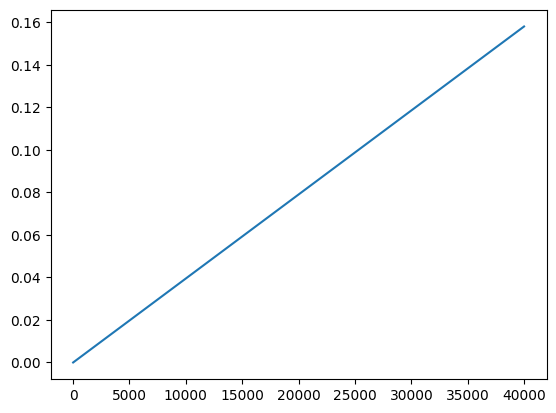

In [49]:
x=np.arange(1, 40000)
plt.plot(x, x * (4000 ** (-1.5)))

In [42]:
np.sqrt(512)

22.627416997969522

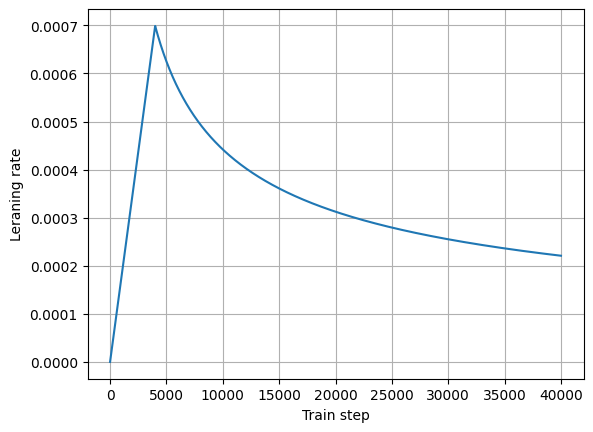

In [60]:
# NoamDecayScheduler 是典型的 Transformer/Attention 类模型中使用的特殊学习率调度器，形式来源于"Attention Is All You Need"论文
# 该调度策略在训练初期迅速增大学习率到最大值（warmup阶段），之后随步数按1/sqrt(step)衰减。
# 公式如下:
#   lr = d_model^(-0.5) * min(step_num^(-0.5), step_num * warmup_steps^(-1.5))
# 其中 d_model 是embedding的维度，通常为512；warmup_steps是学习率预热的轮数（如4000）；step_num为当前训练步数（从1开始）。
class NoamDecayScheduler:
    def __init__(self, config):
        # 从配置参数中读取embedding维度（d_model）和预热步数（warmup_steps）
        self.d_model = config["d_model"]
        self.warmup_steps = config["warmup_steps"]

    def __call__(self, step):
        # step: 当前训练步数（支持int或numpy array），为了公式统一，实际用step+1
        step += 1  # 步数加1避免0次方
        # arg1: 4000步之后的标准衰减分支，随step^-0.5衰减
        arg1 = step ** (-0.5)
        # arg2: warmup阶段增长分支，前warmup_steps步线性上升（归一化，实际乘warmup_steps^-1.5）
        arg2 = step * (self.warmup_steps ** (-1.5))
        # arg3: d_model对学习率全局缩放（论文规定，d_model越大 lr越小）
        arg3 = self.d_model ** (-0.5)
        # 按照论文公式合成实际学习率（预热取min，后续按1/sqrt(step)衰减）
        return arg3 * np.minimum(arg1, arg2)

# 创建一个NoamDecayScheduler示例，用d_model=512, warmup_steps=4000；相当于transformer论文默认配置
temp_learning_rate_schedule = NoamDecayScheduler({"d_model": 512, "warmup_steps": 4000})
# 画图展示调度过程（0~40000步），横坐标为step，纵坐标为学习率
plt.plot(temp_learning_rate_schedule(np.arange(0, 40000)))
plt.ylabel("Leraning rate")  # 学习率y轴
plt.xlabel("Train step")     # 训练步数x轴
plt.grid()
plt.show()


### 优化器

In [ ]:
from torch.optim.lr_scheduler import LambdaLR  # 导入LambdaLR学习率调度器，可以根据给定函数自定义学习率变化方式
from torch.optim import Adam  # 导入Adam优化器

def get_optimizer(model, config):
    """
    构建用于Transformer模型训练的Adam优化器和Noam风格的学习率调度器（NoamDecayScheduler）。

    Args:
        model: 待优化的PyTorch模型，其参数将被优化器管理。
        config: 字典，包含优化器和学习率调度器的参数，例如：
            - "beta1": Adam优化器的一阶矩估计的指数衰减率（通常为0.9）
            - "beta2": Adam优化器的二阶矩估计的指数衰减率（通常为0.98）
            - "eps": Adam优化器的数值稳定项
            - 以及NoamDecayScheduler需要的"d_model"和"warmup_steps"等参数

    Returns:
        optimizer: torch.optim.Adam优化器实例
        scheduler: torch.optim.lr_scheduler.LambdaLR调度器实例（按照Noam策略调整学习率）
    """
    base_lr = 0.1  # 初始化的基础学习率，实际每步会乘以NoamDecayScheduler计算出的比例因子
    beta1 = config["beta1"]  # 查询Adam优化器的beta1超参数（动量项衰减率，默认0.9）
    beta2 = config["beta2"]  # 查询Adam优化器的beta2超参数（平方梯度衰减率，默认0.98）
    eps = config["eps"]      # Adam优化器的epsilon，用于数值稳定
    # 构造Adam优化器，管理模型参数，初始学习率为base_lr
    optimizer = Adam(model.parameters(), lr=base_lr, betas=(beta1, beta2), eps=eps)
    # 实例化NoamDecayScheduler，该对象为一个可调用对象（即函数），根据step数自适应调整实际学习率
    lr_scheduler = NoamDecayScheduler(config)  # config需包含"d_model"和"warmup_steps"
    # 使用LambdaLR构建PyTorch学习率调度器。LambdaLR可以将实际学习率设为 base_lr × lr_lambda(step)
    # 其中lr_lambda就是NoamDecayScheduler对象，实现论文“Attention is All You Need”中的动态策略
    scheduler = LambdaLR(optimizer, lr_lambda=lr_scheduler)
    return optimizer, scheduler  # 返回优化器和学习率调度器

### Callback

In [51]:
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            )

    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,

        )

    def __call__(self, step, **kwargs):
        # add loss
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


In [52]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = - np.inf

        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



In [53]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = - np.inf
        self.counter = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter
            self.counter = 0
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience


### training & valuating

In [ ]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    """
    对模型在给定数据集（如验证集）上的损失进行评估。

    Args:
        model (nn.Module): 待评估的模型。
        dataloader (DataLoader): 验证集或测试集的dataloader。
        loss_fct (callable): 损失函数，通常自定义以支持pad masking。

    Returns:
        float: 整个dataloader上平均损失（标量）。
    """
    loss_list = []  # 用于累计每个batch的损失
    for batch in dataloader:
        # 取出当前batch的编码器输入、掩码，解码器输入与标签，以及标签的掩码
        encoder_inputs = batch["encoder_inputs"]                 # 编码器输入，形状[batch, seq_len]
        encoder_inputs_mask = batch["encoder_inputs_mask"]       # 编码器输入的padding掩码，形状[batch, seq_len]
        decoder_inputs = batch["decoder_inputs"]                 # 解码器输入，形状[batch, seq_len]
        decoder_labels = batch["decoder_labels"]                 # 解码器标签/目标，形状[batch, seq_len]
        decoder_labels_mask = batch["decoder_labels_mask"]       # 解码器标签的padding掩码，形状[batch, seq_len]

        # 前向传播，得到模型输出
        outputs = model(
            encoder_inputs=encoder_inputs,
            decoder_inputs=decoder_inputs,
            encoder_inputs_mask=encoder_inputs_mask
        )
        logits = outputs.logits  # 得到每个位置的类别logit分布，形状[batch, tgt_len, vocab_size]

        # 计算当前batch的损失，通常应考虑padding掩码以忽略pad部分对损失的影响
        loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)  # 单个标量
        loss_list.append(loss.cpu().item())  # 取出数值，并转到CPU，加入loss列表

    # 返回所有batch损失的均值，作为评估指标（如验证集平均损失）
    return np.mean(loss_list)


In [55]:
# 训练主函数：负责模型的完整训练流程，包括正向传播、损失回传、记录日志、评估、可视化、保存模型和早停
def training(
    model,
    train_loader,            # 训练集的Dataloader（包含分batch好的输入）
    val_loader,              # 验证集的Dataloader，用于模型评估
    epoch,                   # 总共训练的轮数
    loss_fct,                # 损失函数，已支持mask以跳过pad区域
    optimizer,               # 优化器（如Adam等）
    scheduler=None,          # 学习率调度器（optional，可选，用于动态调整lr）
    tensorboard_callback=None,      # tensorboard记录回调，用于可视化监控
    save_ckpt_callback=None,        # 写模型ckpt的回调函数
    early_stop_callback=None,       # 早停回调
    eval_step=500,                  # 评估步长，每eval_step进行一次验证
    ):
    # 记录训练与验证损失变化，方便可视化分析
    record_dict = {
        "train": [],  # 每步的训练损失与step编号
        "val": []     # 每eval_step的验证损失
    }

    global_step = 1            # 记录当前的迭代步数，全局唯一
    model.train()              # 设置模型为train模式，启用dropout等
    with tqdm(total=epoch * len(train_loader)) as pbar:  # tqdm用于显示训练进度条
        for epoch_id in range(epoch):                    # 多轮(epoch)训练
            # 遍历每一批batch数据
            for batch in train_loader:
                # 1. 从batch中取输入与标签、相关mask
                encoder_inputs = batch["encoder_inputs"]                 # [batch, src_len]
                encoder_inputs_mask = batch["encoder_inputs_mask"]       # [batch, src_len], padding mask (True为有效，False为pad)
                decoder_inputs = batch["decoder_inputs"]                 # [batch, tgt_len]
                decoder_labels = batch["decoder_labels"]                 # [batch, tgt_len]
                decoder_labels_mask = batch["decoder_labels_mask"]       # [batch, tgt_len], target的有效mask

                # 2. 梯度清零，防止累加
                optimizer.zero_grad()

                # 3. 前向传播
                outputs = model(
                    encoder_inputs=encoder_inputs,
                    decoder_inputs=decoder_inputs,
                    encoder_inputs_mask=encoder_inputs_mask
                    )
                logits = outputs.logits  # [batch, tgt_len, vocab_size]，未归一化的logits

                # 4. 计算损失，忽略pad位置（依靠mask）
                loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)

                # 5. 后向传播，累计梯度
                loss.backward()

                # 6. 更新模型参数
                optimizer.step()
                if scheduler is not None:
                    scheduler.step() # 若有学习率调度器，则更新lr到optimizer

                # 记录损失数值（转cpu，转为float）
                loss_val = loss.cpu().item()
                record_dict["train"].append({
                    "loss": loss_val, "step": global_step
                })

                # 7. 按设定步数评估（eval_step）：验证集损失、可视化、early stop等
                if global_step % eval_step == 0:
                    model.eval()  # 切换到eval，关闭dropout
                    val_loss = evaluating(model, val_loader, loss_fct)  # 验证集loss
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train() # 恢复为train模式，保证dropout等生效

                    # 7.1 可选: Tensorboard可视化
                    # 当前学习率: 优先scheduler的（因为优化器的lr未必是最新），否则用优化器的
                    cur_lr = optimizer.param_groups[0]["lr"] if scheduler is None else scheduler.get_last_lr()[0]
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss_val, val_loss=val_loss,
                            lr=cur_lr,
                            )

                    # 7.2 可选: 保存模型ckpt
                    # metric用负val_loss(更小越好)体现优劣
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 7.3 可选: 早停机制
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss) # metric越大越好，使用负的val_loss
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict  # 提前结束训练流程

                # 更新step与进度条
                global_step += 1
                pbar.update(1)
            # 每个epoch结束，在tqdm进度条上显示loss和最新val_loss
            # val_loss通常在最后一次eval_step之后才被赋值，如果训练步数不是eval_step整数倍需要注意
            pbar.set_postfix({"epoch": epoch_id, "loss": loss_val, "val_loss": val_loss})

    return record_dict   # 返回完整的训练/验证损失日志，方便后续画图


In [ ]:
# 模型超参数配置，涵盖Transformer的结构及训练设置
config = {
    "bos_idx": 1,               # 句子起始符（BOS）对应的词表索引
    "eos_idx": 3,               # 句子结束符（EOS）对应的词表索引
    "pad_idx": 0,               # <pad>符号对应的词表索引（用于padding补齐）
    "vocab_size": len(word2idx),# 词表大小（根据已加载的字典自动赋值），决定Embedding等维度
    "max_length": 512,          # 输入序列最大长度，训练/推理时的截断长度（数据预处理仍使用原有设置）
    "d_model": 512,             # Transformer主干处理的hidden size，可调整（通常为512/256/1024等）
    "dim_feedforward": 3072,    # FFN（前馈全连接层）的中间维度（略大于4倍d_model），提升模型表达能力
    "dropout": 0.1,             # dropout概率，可适度调整防止过拟合
    "layer_norm_eps": 1e-6,     # 层归一化的小常数，防止分母为0
    "num_heads": 8,             # 多头注意力的头数，原论文为8（需能整除d_model）
    "num_decoder_layers": 8,    # Decoder堆叠层数（利用32GB显存，适当增加层数以提升性能）
    "num_encoder_layers": 8,    # Encoder堆叠层数（同上）
    "label_smoothing": 0.1,     # 标签平滑超参数，提升泛化能力，通常0.1
    "beta1": 0.9,               # Adam优化器beta1参数（动量估计）
    "beta2": 0.98,              # Adam优化器beta2参数（均方根估计）
    "eps": 1e-9,                # Adam优化器的epsilon（避免除零）
    "warmup_steps": 8000,       # 预热步数，配合更深模型适当增大，训练更稳定
    "share_embedding": False,   # 是否共享编码/解码Embedding权重（论文有实验，实际效果需视具体任务）
}

def get_dl(dataset, batch_size, shuffle=True):
    """
    该函数根据给定数据集、batch_size及shuffle标志，生成适用于Transformer场景的dataloader。
    - TransformerBatchSampler 根据样本长度进行分批，提高padding效率。
    - collate_fn 使用collate_fct并传入tokenizer，实现自定义批处理拼接。
    - 返回：pytorch DataLoader对象
    """
    sampler = TransformerBatchSampler(dataset, batch_size=batch_size, shuffle_batch=shuffle)
    sample_dl = DataLoader(dataset, batch_sampler=sampler, collate_fn=partial(collate_fct, tokenizer=tokenizer))
    return sample_dl

# 构建训练集、验证集的LangPairDataset对象（加载已分好train/val的数据，自动截断长度）
train_ds = LangPairDataset("train", max_length=config["max_length"])
val_ds = LangPairDataset("val", max_length=config["max_length"])

# 构建分词器Tokenizer
# - word2idx: 词到索引的映射（用于ID化原始文本）
# - idx2word: 索引到词的映射（用于解码ID为文本）
# - max_length: 最大支持的句子长度
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word, max_length=config["max_length"])

batch_size = 4096   # 利用32GB显存，将token级batch size增大到4096，提高训练稳定性和效果

# DataLoader构建, get_dl内含样本动态分batch策略
train_dl = get_dl(train_ds, batch_size=batch_size, shuffle=True)   # 训练集打乱顺序
val_dl = get_dl(val_ds, batch_size=batch_size, shuffle=False)      # 验证集顺序读取，评估时不打乱

save cache to wmt16\.cache\de2en_train_128.npy
save cache to wmt16\.cache\de2en_val_128.npy


In [51]:
#计算模型参数量
model = TransformerModel(config)
print(f"模型参数量: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

模型参数量: 71938239


In [57]:
config

{'bos_idx': 1,
 'eos_idx': 3,
 'pad_idx': 0,
 'vocab_size': 18111,
 'max_length': 128,
 'd_model': 512,
 'dim_feedforward': 2048,
 'dropout': 0.1,
 'layer_norm_eps': 1e-06,
 'num_heads': 8,
 'num_decoder_layers': 6,
 'num_encoder_layers': 6,
 'label_smoothing': 0.1,
 'beta1': 0.9,
 'beta2': 0.98,
 'eps': 1e-09,
 'warmup_steps': 4000,
 'share_embedding': False}

In [ ]:
# 设置训练的总轮数（epoch），每个epoch表示遍历一次全部训练数据
epoch = 30  # 利用更大显存与更深模型，适当增加训练轮数

# 构建Transformer模型实例，并传入超参数配置字典
model = TransformerModel(config)

# 1. 定义损失函数。此处采用包含padding忽略的交叉熵损失（适用于翻译任务），自动忽略pad标签
loss_fct = CrossEntropyWithPadding(config)

# 2. 定义优化器与学习率调度，采用Adam优化器（带有Transformer自定义warmup学习率调整方案）
# 返回优化器对象optimizer和学习率调度器scheduler
optimizer, scheduler = get_optimizer(model, config)

# 3. 配置TensorBoard可视化。自动新建日志文件夹runs/，用于存放可视化结果
if not os.path.exists("runs"):
    os.mkdir("runs")
# 实验记录名，便于区分不同模型结构的实验日志（是否共享Embedding）
exp_name = "translate-transformer-{}".format("share" if config["share_embedding"] else "not-share")
# 构造TensorBoard回调，将在runs/exp_name路径下记录指标与可视化数据
tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")
# 如需可视化网络结构，可调用下方方法（需安装graphviz和pytorch相关支持）
# tensorboard_callback.draw_model(model, [1, MAX_LENGTH])

# 4. 配置模型Checkpoint保存（断点与最优模型），存放于checkpoints/exp_name目录
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback(
    f"checkpoints/{exp_name}", save_step=500, save_best_only=True)

# 5. 提前终止回调（EarlyStop），若验证集loss超过8个验证周期未提升则早停（防止过拟合）
early_stop_callback = EarlyStopCallback(patience=8)

# 将模型移动到指定设备（如cuda:0或cpu），确保后续训练和推理在正确的硬件上进行
model = model.to(device)

# 6. 启动训练主循环
# - 传入：模型、训练集/验证集DataLoader、epoch数、损失函数、优化器与调度器
# - tensorboard_callback：用于记录训练过程的可视化信息
# - save_ckpt_callback：自动保存模型权重快照
# - early_stop_callback：用于提前终止的回调函数
# - eval_step：每多少步做一次验证评估
record = training(
    model,
    train_dl,
    val_dl,
    epoch,
    loss_fct,
    optimizer,
    scheduler,
    tensorboard_callback=tensorboard_callback,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,  # 启用EarlyStop，根据验证集表现自动早停
    eval_step=500
    )

# 对比（注释）：原Transformer论文中base模型（6层encoder/decoder）训练10万步，或12小时，大模型30万步耗时3.5天。代码中的训练步数和硬件配置可根据实际情况调整。

  0%|          | 0/280 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 推理

- 翻译项目的评估指标一般是BLEU4，感兴趣的同学自行了解并实现
- 接下来进行翻译推理，并作出注意力的热度图

In [ ]:
# 安装 Cython 库（为后续编译 fastBPE 依赖环境，若安装 fastBPE 失败建议先运行本行）
%pip install Cython  

# 使用Cython编译器的情况下，安装和运行会更快，fastBPE等需要C扩展的库编译更顺利
# 比如在命令行安装时（%pip install Cython），再安装fastBPE会自动用Cython帮助编译C语言扩展模块，提高运行效率。
# 不使用Cython的情况下，安装含C扩展部分的库可能会失败，或者运行速度较慢，部分依赖包无法编译成功，导致安装出错或者性能下降。

# 中间结果指的是：在分词操作时，原始文本经过一次子词切分后生成的临时文本文件或数据。如果用普通BPE（如subword-nmt）工具，每一步BPE编码都要把当前的文本结果写到磁盘文件，再作为下一步输入读出来，这就会产生“中间结果文件”，导致反复磁盘IO。而 fastBPE 直接在内存数据结构中进行处理，不用保存这些临时的“中间结果”到硬盘上，所以速度更快也更省IO资源。

# fastBPE和普通BPE（如subword-nmt）的主要区别在于数据处理时的IO方式：
# - fastBPE 使用C++实现，分词时数据直接在内存中操作，无需将中间结果反复写入磁盘文件，因此速度更快，占用更少的IO资源，特别适合大规模语料和多次分词流水线操作。
# - 普通BPE（如subword-nmt）通常基于Python实现，每一步分词后会产生中间文件，需要频繁地读写磁盘，过程依赖于文件系统，处理大数据时磁盘IO成为瓶颈，运行会慢很多。
# 简言之：fastBPE 主要优点是“内存处理、极少磁盘读写”，普通BPE的大流量操作则依赖磁盘，速度和效率不及fastBPE。

# 安装 fastBPE 工具包（快速BPE分词工具，分词可以直接在内存中处理，无需将中间数据写回文件；也可用 subword-nmt 命令行工具作为替代）
%pip install fastBPE  

# 补充说明：在 Windows 系统中并不存在 sys/mman.h 文件，若编译/安装时报 mman.h 相关错误，仅适用于 Linux/Mac，且 fastBPE 在 Windows 下支持有限

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 41.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Using cached https://mirrors.cloud.aliyuncs.com/pypi/packages/e1/37/f97181428a5d151501b90b2cebedf97c81b034ace753606a3cda5ad4e6e2/fastBPE-0.1.0.tar.gz (35 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for fastBPE: filename=fastBPE-0.1.0-cp310-cp310-linux_x86_64.whl size=807200 sha256=df86c0131a172aa794ccf5f1ad14d3740a17890512a4c7b384e58ed9f5c5c5b5
  Stored in directory: /root/.cache/pip/wheels/1d/0e/8b/95330f4ce22158266a1989a849aa21eb10e679bbc4f54b743b
Successfully built fastBPE

[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [59]:
!ls checkpoints/translate-transformer-not-share/

best.ckpt


In [60]:
!cp checkpoints/translate-transformer-not-share/best.ckpt .

In [ ]:
import torch

state_dict = torch.load(f"best.ckpt", map_location="cpu") #本地用的，云上要修改路径为
 
# state_dict1 = torch.load("epoch125-step132426.ckpt", map_location="cpu")
# state_dict = state_dict1["state_dict"]

# update keys by dropping `model`
# for key in list(state_dict):
#     state_dict[key.replace("model.", "")] = state_dict.pop(key)


/tmp/ipykernel_413/2586229630.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f"best.ckpt", map_location="cpu") #本地用的，云上要修改路径为


In [ ]:
# !pip install nltk

In [ ]:
# !rm -r wmt16/.cache

In [58]:
tokenizer.decode([[   5,   16,    6,   23,  150,   80, 8248,   35,  232,    4,    3]])

['a man in an seinem hat sh-@@ at guitar .']

In [ ]:
from nltk.translate.bleu_score import sentence_bleu
# 在这里没有用到infer的原因是，此处直接拿模型加载好权重后，在评测部分用的是标准的验证/测试循环，
# 通过提供decoder_inputs（通常是目标句子的shift-right版，即teacher forcing）和源句子，
# 直接用模型计算logits与交叉熵损失来衡量模型对每个样本的拟合程度。
# infer函数一般是在实际推理/生成阶段（如beam search或者贪婪解码），
# 用于只给定源句子，让模型自回归生成目标句子（比如在生产部署、测试生成句子/翻译时）。
# 而这里主要目的是计算损失（方便与训练过程统一、对齐模型结果），所以直接用模型forward输出logits计算loss，不需要真实的推理生成过程，所以没用infer。

# 说明：你提出的是预测/推理阶段的解码流程问题，这里详细讲一下区别！

# 在训练和评估时，常见有两种方式：
# 1. 训练/验证阶段（包括这个步骤）：为了最大化并行效率和充分梯度利用，采用"teacher forcing"——
#    即decoder输入是目标序列的前n-1个token，标签是目标的第2到n个token。
#    此时，模型一次性前向就能输出所有token，每个时间步的预测能与label直接对齐，能有效利用GPU并行。
#    这种方式方便损失计算，且和训练完全统一。
#
# 2. 实际生成/测试阶段（如部署推理、生成翻译），则通常采用自回归方式(greedy/beam search等)：
#    - decoder每次只输入<sos>和前面已生成的token，预测下一个token；
#    - 预测得到下一个token后，将其拼接到decoder_input后，再次送入模型，循环直到eos或最大长度。
#    - 这种方式不能并行，只能逐步生成，效率低，但是模拟真实生成情景。

# 这段代码之所以在评测时直接喂入目标序列（即使用teacher forcing），
# 是为了方便与训练过程对齐，计算整个目标序列的平均损失(likelihood)，
# 用于比较模型在验证集/测试集上的学习和拟合程度——
# 这是学术/开发中很常见的一种评估做法。
#
# 如果你想评估真实的“生成”能力，可以写独立的推理循环，像infer/beam_search那样每次喂入部分、逐步生成。
#
# 结论：这里的“预测”（严格说是评测），并不是实际生成推理（不会一步一步生成），
# 而是用目标全序列做teacher forcing（并行），只为统计loss对比训练表现，
# 这样做是“对的”，不是在真正做自回归生成！


# ---------- 模型加载及推理评测（详细注释版） ----------

# 1. 加载Transformer结构的模型
model = TransformerModel(config)
# 加载预训练参数权重到模型
model.load_state_dict(state_dict)

# 2. 定义损失函数：交叉熵损失，自动忽略padding部分
loss_fct = CrossEntropyWithPadding(config)

# 3. 构建测试数据集和数据加载器
#   - LangPairDataset: 加载指定数据集(split="test")，用最大长度512处理
#   - DataLoader: 封装数据，每次读取一个样本并使用collate_fn做batch内张量拼接和tokenization
test_ds = LangPairDataset("test", max_length=512, data_dir="./wmt16")
test_dl = DataLoader(test_ds, batch_size=1, collate_fn=partial(collate_fct, tokenizer=tokenizer))

# 4. 模型转移到计算设备（如GPU），并设置为eval模式（关闭dropout等）
model = model.to(device)
model.eval()

collect = {}         # 记录每个样本loss和详细中间变量的字典
loss_collect = []    # 记录每个样本loss的列表

predictions = []     # 预测句子（暂未用到）
answers = []         # 参考答案（暂未用到）

# 5. 计算BLEU分数的结果列表（BLEU是一种衡量翻译质量的自动评估指标）
bleu_scores = []

# 6. 遍历所有测试数据，逐条推理和评估
for idx, batch in tqdm(enumerate(test_dl)):
    # 取出当前batch的各项输入（均为tensor, shape: [1, seq_len]）
    encoder_inputs = batch["encoder_inputs"]                 # 源语言输入
    encoder_inputs_mask = batch["encoder_inputs_mask"]       # 源输入mask
    decoder_inputs = batch["decoder_inputs"]                 # 目标语言输入(teacher forcing时使用)
    decoder_labels = batch["decoder_labels"]                 # 目标语言标签(ground truth)

    # print(decoder_labels.cpu())  # 可打印出真实标签对应的索引
    # decoder_labels1=tokenizer.decode(decoder_labels.cpu().numpy())  # 可恢复为字符串
    # 前向计算，获得模型输出logits
    outputs = model(
        encoder_inputs=encoder_inputs,
        decoder_inputs=decoder_inputs,
        encoder_inputs_mask=encoder_inputs_mask
    )

    # 计算损失: CrossEntropy损失，自动忽略PAD符号（测试集通常batch_size=1，不需加额外mask）
    loss = loss_fct(outputs.logits, decoder_labels)
    # print(outputs.logits.shape, decoder_labels.shape)  # debug shape信息

    # 调用argmax得到预测的词索引序列
    preds = outputs.logits.argmax(dim=-1)       # 预测序列: [batch, seq_len]
    # print(preds.shape)

    # 通过tokenizer，将预测索引序列恢复为英文句子文本列表（形如['the cat jumps ...']）
    preds = tokenizer.decode(preds.cpu().numpy())
    # print(preds)

    # 参考target，将真实标签索引序列恢复成英文句子（同上，list of str）
    decoder_labels = tokenizer.decode(decoder_labels.cpu().numpy())
    # print(decoder_labels)

    # 计算该样本的BLEU分数（unigram，即只统计1-gram准确率，weights=(1,0,0,0)）,以当前样本ground-truth为reference
    belu = sentence_bleu([decoder_labels[0].split()], preds[0].split(), weights=(1, 1, 1, 1))
    bleu_scores.append(belu)    # 记录BLEU分数

    # 收集各类变量，便于后续排序展示、误差分析等
    collect[idx] = {
        "loss": loss.item(),
        "src_inputs": encoder_inputs,
        "trg_inputs": decoder_inputs,
        "mask": encoder_inputs_mask,
        "trg_labels": decoder_labels,    # [str]
        "preds": preds                   # [str]
    }
    loss_collect.append(loss.item())     # 记录损失

    # 如果只想看一个batch结果，可break
    # break

# 7. 按照loss升序，对collect中的样本排序，便于分析模型效果最好的案例
collect = sorted(collect.items(), key=lambda x: x[1]["loss"])

# 8. 输出平均测试集loss
print(f"testing loss: {np.array(loss_collect).mean()}")

# 9. 输出平均BLEU分数（可用于衡量当前模型整体翻译质量）
sum(bleu_scores) / len(bleu_scores)

save cache to wmt16/.cache/de2en_test_128.npy


0it [00:00, ?it/s]/usr/local/lib/python3.10/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))
/usr/local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
18it [00:00, 90.35it/s]/usr/local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning:

testing loss: 3.4247257990866715


0.5633111443369839

Loading vocabulary from ./wmt16/vocab ...
Read 762259 words (18107 unique) from vocabulary file.
Loading codes from ./wmt16/bpe.20000 ...
Read 20001 codes from the codes file.
 13%|█▎        | 17/128 [00:00<00:03, 36.90it/s]
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


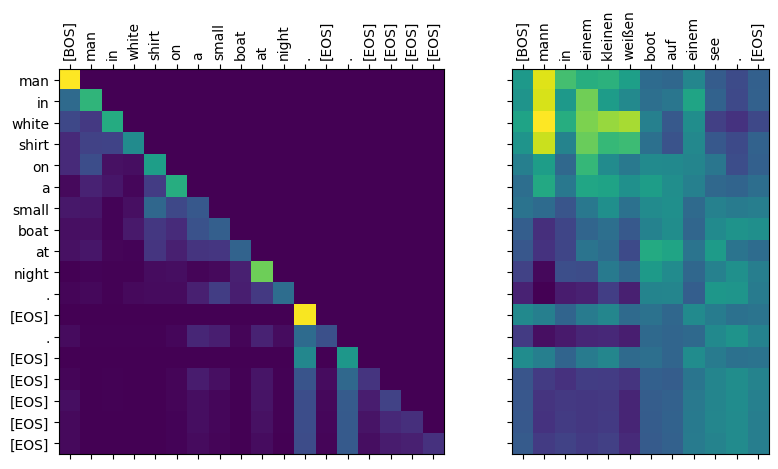

/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


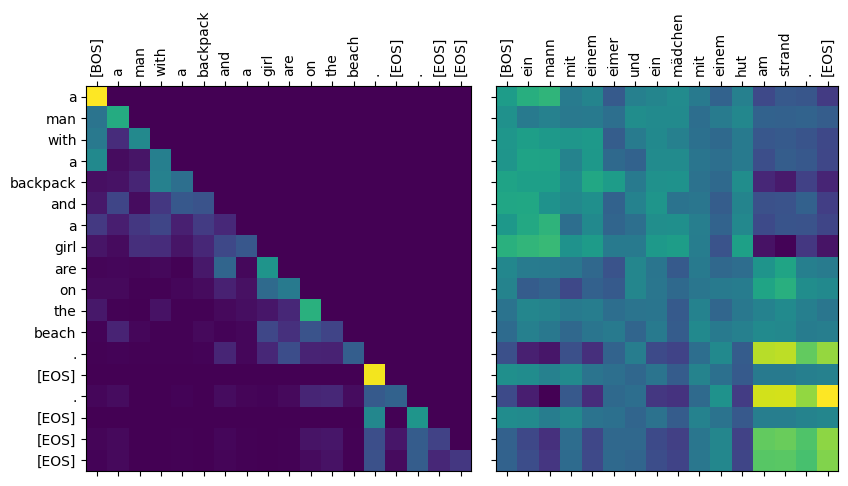

/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


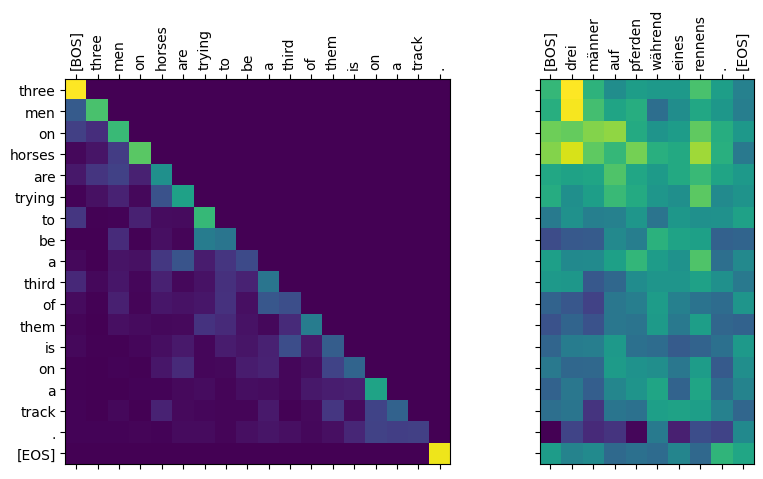

/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


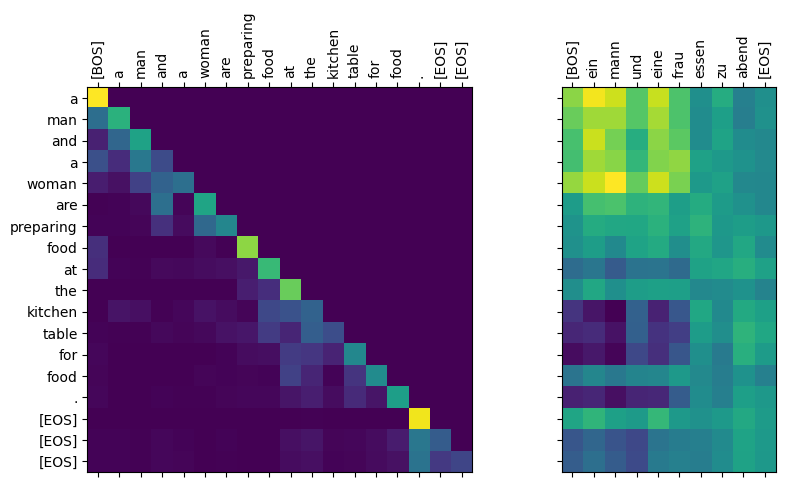

['man in white shirt on a small boat at night.',
 'a man with a backpack and a girl are on the beach.',
 'three men on horses are trying to be a third of them is on a track.',
 'a man and a woman are preparing food at the kitchen table for food.']

In [ ]:
# 这一部分代码是用于推理阶段的翻译与可视化分析工具，主要实现了如下功能：
# 1. 利用事先训练完成并保存的Transformer模型，对任意指定的德语句子（或德语句子列表）进行英文翻译，并返回最终翻译结果。
# 2. 通过整合MosesTokenizer/MosesDetokenizer（sacremoses库）以及fastBPE，实现对测试/输入文本的严格与训练阶段一致的分词、BPE分段、去BPE粘连等预处理和后处理。
# 3. 编写了Translator类，除翻译功能外，提供注意力权重（自注意力与交叉注意力）的可视化方法，方便直观分析模型推理时每个单词的关注分布，从而对模型的行为和错误原因作进一步解释。
# 
# 与上面（训练与批量评估部分）的区别：
# - 上面的代码是评估全测试集，输出整体Loss/BLEU等指标，用于整体性能度量，主要对象是对现有数据集的自动遍历与统计；不会关注个别样本的详细推理和可视化。
# - 本段代码更偏重单条、部分案例分析和手动可视化。它允许用户输入任意德语句子，获得模型的推理结果，并绘制详细的注意力分布热力图，辅助人类理解Transformer模型所学的对齐机制以及翻译细节。
# - 特别适合调试、答辩演示、模型解释、查找典型成功和失败样例。
# 
# 下面是具体代码，使用方法见最下方注释部分。

import re
from fastBPE import fastBPE
from sacremoses import MosesDetokenizer, MosesTokenizer

# `MosesTokenizer` 和 `MosesDetokenizer` 是来自 `sacremoses` 库的工具，用于自然语言处理中的分词（Tokenization）和去标记化（Detokenization）。这些工具主要用于对文本进行预处理和后处理，通常在处理自然语言处理任务时会用到。
#
# ### MosesTokenizer：
# - **作用**：将原始文本分割成单词和标点符号。
# - **特点**：基于 Moses 翻译工具中使用的分词方法。
# - **功能**：
#   - 将句子分割成单词和标点符号。
#   - 处理缩写、连字符、标点等特殊情况。
#   - 对文本进行标记化，方便后续处理。
#
# ### MosesDetokenizer：
# - **作用**：将分词后的文本重新组合成原始的句子。
# - **特点**：用于对分词后的文本进行还原，使其恢复为可读的句子形式。
# - **功能**：
#   - 将分词后的单词和标点符号重新组合成句子。
#   - 处理分词后的标点、缩写等情况，使得结果更加自然和可读。
#
# 这些工具通常在文本预处理和后处理过程中使用，对输入的文本进行标记化和去标记化，是一种常用的处理方式。在自然语言处理任务中，对文本进行正确的分词和还原是很重要的，而 `MosesTokenizer` 和 `MosesDetokenizer` 提供了方便、高效的工具来处理这些任务。

class Translator:
    def __init__(self, model, src_tokenizer, trg_tokenizer):
        # 初始化BPE分词器，加载BPE codes文件和词表文件
        # fastBPE 用于将原始文本切分为子词单元（与训练完全一致，保证推理一致性）
        self.bpe = fastBPE("./wmt16/bpe.20000", "./wmt16/vocab")
        
        # 初始化Moses分词器，用于德语句子的tokenize处理
        # MosesTokenizer用于对德语输入分词（前处理），比如处理特殊符号、变形、连字符等
        self.mose_tokenizer = MosesTokenizer(lang="de")
        
        # 初始化Moses去分词器，用于英语的detokenize处理
        # MosesDetokenizer用于将模型输出（通常为token拼接）还原为连续、可读的英文文本
        self.mose_detokenizer = MosesDetokenizer(lang="en")
        
        # 保存Transformer模型对象并切换至评估模式
        # 这样可确保不会有梯度更新/BN/Dropout等训练中行为影响推理
        self.model = model
        self.model.eval()
        
        # 保存分词器（Tokenizer）对象
        # src_tokenizer：源语言侧（德语）分词器，负责编码德语作为模型输入
        # trg_tokenizer：目标语言侧（英语）分词器，负责将模型输出的token还原为英文句子
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer
        
        # 用于处理BPE的特殊标记（如“@@”粘连），保持和训练一致
        # 该pattern用于去除BPE分词后token之间不完整单词的符号
        self.pattern = re.compile(r'(@@ )|(@@ ?$)')

    def draw_attention_map(self, attn_scores, cross_attn_scores, src_words_list, trg_words_list):
        """绘制注意力热力图
        attn_scores (numpy.ndarray): 表示自注意力机制（self-attention）分数。
        cross_attn_scores (numpy.ndarray): 表示交叉注意力机制的注意力分数。
        src_words_list (list): 源语言句子的单词列表。
        trg_words_list (list): 目标语言句子的单词列表。
        """
        assert len(attn_scores.shape) == 3, "attn_scores shape should be " \
            f"[num heads, target sequence length, target sequence length], but got {attn_scores.shape}"
        attn_scores = attn_scores[:, :len(trg_words_list), :len(trg_words_list)]

        assert len(cross_attn_scores.shape) == 3, "attn_scores shape should be " \
            f"[num heads, target sequence length, source sequence length], but got {cross_attn_scores.shape}"
        cross_attn_scores = cross_attn_scores[:, :len(trg_words_list), :len(src_words_list)]

        num_heads, trg_len, src_len = cross_attn_scores.shape

        fig = plt.figure(figsize=(10, 5), constrained_layout=True) # constrained_layout=True 自动调整子图参数，使之填充整个图像区域
        grid = plt.GridSpec(trg_len, trg_len + src_len, wspace=0.1, hspace=0.1)# wspace,hspace 控制子图之间的间距
        #下面是attn_scores的热力图
        self_map = fig.add_subplot(grid[:,:trg_len]) #  添加子图
        self_map.matshow(attn_scores.mean(dim=0), cmap='viridis') # 绘制热力图，cmap表示颜色,dim=0表示对第0维求均值
        self_map.set_yticks(range(trg_len), trg_words_list, fontsize=10)
        self_map.set_xticks(range(trg_len), ["[BOS]"] + trg_words_list[:-1], rotation=90)
        #下面是cross_attn_scores的热力图
        cross_map = fig.add_subplot(grid[:, trg_len:])
        cross_map.matshow(cross_attn_scores.mean(dim=0), cmap='viridis')
        cross_map.set_yticks(range(trg_len), [], fontsize=6)
        cross_map.set_xticks(range(src_len), src_words_list, rotation=90)

        plt.show()

    def draw_attention_maps(self, attn_scores, cross_attn_scores, src_words_list, trg_words_list, heads_list):
        """绘制注意力热力图

        Args:
            - scores (numpy.ndarray): shape = [source sequence length, target sequence length]
        """
        assert len(attn_scores.shape) == 3, "attn_scores shape should be " \
            f"[num heads, target sequence length, target sequence length], but got {attn_scores.shape}"
        attn_scores = attn_scores[:, :len(trg_words_list), :len(trg_words_list)]

        assert len(cross_attn_scores.shape) == 3, "attn_scores shape should be " \
            f"[num heads, target sequence length, source sequence length], but got {cross_attn_scores.shape}"
        cross_attn_scores = cross_attn_scores[:, :len(trg_words_list), :len(src_words_list)]
        # cross_attn_scores = cross_attn_scores[:, :len(src_words_list), :len(src_words_list)]

        num_heads, trg_len, src_len = cross_attn_scores.shape
        fig, axes = plt.subplots(2, len(heads_list), figsize=(5 * len(heads_list), 10))
        for i, heads_idx in enumerate(heads_list):
            axes[0, i].matshow(attn_scores[heads_idx], cmap='viridis')
            axes[0, i].set_yticks(range(trg_len), trg_words_list)
            axes[0, i].set_xticks(range(trg_len), ["[BOS]"] + trg_words_list[:-1], rotation=90)
            axes[0, i].set_title(f"head {heads_idx}")
            axes[1, i].matshow(cross_attn_scores[heads_idx], cmap='viridis')
            axes[1, i].set_yticks(range(trg_len), trg_words_list)
            axes[1, i].set_xticks(range(src_len), src_words_list, rotation=90)
            axes[1, i].set_title(f"head {heads_idx}")

        plt.show()


    def __call__(self, sentence_list, heads_list=None, layer_idx=-1):
        """
        进行翻译推理并可视化注意力。

        Args:
            sentence_list (list[str]): 原始输入句子列表（源语言）。
            heads_list (list[int], optional): 若指定则可视化指定注意力头的热力图，否则画全部平均。
            layer_idx (int): 指定Transformer层，可为负数表示倒数第几层。

        Returns:
            list[list[str]]: 翻译后的目标语言句子（已去标记化，分词结果）。
        """
        # 步骤1：先将所有输入句子转为小写，防止大小写影响分词及BPE效果
        # 使用MosesTokenizer（更适合多语种）分词，将每句变成空格拼接的token串
        sentence_list = [
            " ".join(self.mose_tokenizer.tokenize(s.lower())) 
            for s in sentence_list
        ]

        # 步骤2：对分词后的句子应用Byte-Pair Encoding（BPE）子词分割
        # 得到BPE编码后的token列表（原词单元会拆分为子词单元，便于词表泛化）
        # bpe.apply返回字符串，这里再split成list
        
        # 这里 bpe.apply(sentence_list) 的作用是对分词后的句子列表依次进行 Byte-Pair Encoding (BPE) 子词分割。
        # 每个原始句子首先通过分词器（如 MosesTokenizer）分词，变为空格分隔的 token 字符串（如 "a man in a hat"）。
        # bpe.apply 会将这些 token 串进一步切分为更细粒度的子词单元，例如词频较低的词会被分成多个常见的子词，有助于模型泛化和压缩词表。
        # 得到的结果是每个句子被 BPE 分割后的 subword token 字符串（仍以空格分隔），
        # 例如 "shattered" 可能被分为 "sh@@ attered"，便于后续根据子词表编码为 id。
        tokens_list = [s.split() for s in self.bpe.apply(sentence_list)]

        # 步骤3：用编码器tokenizer将BPE后token序列编码为ID
        # 并加起始、结束标记，同时返回注意力Mask（padding处为0，其它为1）
        encoder_input, attn_mask = self.src_tokenizer.encode(
            tokens_list,
            add_bos=True,   # 添加开头[BOS]
            add_eos=True,   # 添加结尾[EOS]
            return_mask=True,
        )

        # 步骤4：转换成PyTorch LongTensor（模型推理需要）
        encoder_input = torch.Tensor(encoder_input).to(dtype=torch.int64)

        # 步骤5：前向推理。将编码后的输入和注意力mask送入模型，获取outputs
        # outputs结构通常包含：预测序列preds、以及多层的注意力矩阵等
        outputs = model.infer(
            encoder_inputs=encoder_input, 
            encoder_inputs_mask=attn_mask
        )

        # 步骤6：解码模型预测结果
        # 将预测的ID序列还原为token字符串（未拼接，画图时会用到），方便后续注意力可视化
        preds = outputs.preds.numpy()
        trg_decoded = self.trg_tokenizer.decode(
            preds, 
            split=True, 
            remove_eos=False, 
            remove_bos=False, 
            remove_pad=False
        )  # 未拼接，仍是子词单元列表

        # 步骤7：同理，将编码器输入（源ID序列）解码为源语言的token列表（含BPE标记）
        # 用于attention热力图的坐标说明
        src_decoded = self.src_tokenizer.decode(
            encoder_input.numpy(),
            split=True,
            remove_bos=False, # 保留BOS&EOS用于标记齐一致
            remove_eos=False
        )

        # 步骤8：根据传入参数可视化注意力
        # zip配对每个句子的自注意力、交叉注意力、源序列、目标序列
        # 这里outputs.decoder_self_attn_scores和outputs.decoder_cross_attn_scores
        # 通常是list/array，形状为[layer数, batch, head, tgt_len, src_len]等,
        # 只取指定层layer_idx（如-1为最后一层），并遍历batch维度
        for attn_score, cross_attn_score, src, trg in zip(
            outputs.decoder_self_attn_scores[layer_idx],    # [batch, head, ...)
            outputs.decoder_cross_attn_scores[layer_idx],   # [batch, head, ...)
            src_decoded,                                   # 源token列表
            trg_decoded                                    # 目标token列表
        ):
            if heads_list is None:
                # 没有指定head，则画每个样本整个注意力均值热力图，
                # 即所有attention head沿head维均值（融合多头信息）
                self.draw_attention_map(
                    attn_score,
                    cross_attn_score,
                    src,
                    trg,
                )
            else:
                # 指定了head列表，分别画指定head的单独热力图
                self.draw_attention_maps(
                    attn_score,
                    cross_attn_score,
                    src,
                    trg,
                    heads_list=heads_list,
                )

        # 步骤9：返回翻译后的目标语言句子
        # 先将preds再次decode（默认拼接成字符串），
        # pattern.sub把token串中的特殊字符去掉，再分词，
        # 最后通过MosesDetokenizer将目标子词去bpe、还原为可读文本
        return [
            self.mose_detokenizer.tokenize(self.pattern.sub("", s).split()) 
            for s in self.trg_tokenizer.decode(preds)
        ]



# sentence_list = [
#     "Mann in einem kleinen weißen Boot auf einem See.",  # Man in a small white boat on a lake.
#     "Ein Mann mit einem Eimer und ein Mädchen mit einem Hut am Strand.", # A man with a bucket and a girl in a hat on the beach.
#     "Drei Männer auf Pferden während eines Rennens.",  # Three men on horses during a race.
#     "Ein Mann und eine Frau essen zu Abend",  # 一个男人和一个女人在吃晚餐
# ]
sentence_list = [
    # "Mann in einem kleinen weißen Boot auf einem See.",  # Man in a small white boat on a lake.
    "Ein Mann mit einem Eimer und ein Mädchen mit einem Hut am Strand.", # A man with a bucket and a girl in a hat on the beach.
    # "Drei Männer auf Pferden während eines Rennens.",  # Three men on horses during a race.
    # "Ein Mann und eine Frau essen zu Abend",  # 一个男人和一个女人在吃晚餐
]

# load checkpoints
model = TransformerModel(config)
model.load_state_dict(state_dict)
translator = Translator(model.cpu(), tokenizer, tokenizer)
translator(
    sentence_list,
    layer_idx=-1,
    # heads_list=[0, 1, 2, 3, 4, 5, 6, 7]
    )


In [ ]:
!ls checkpoints